In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pymannkendall as mk
from scipy import stats

## Load in SINCA Data

In [2]:
folder = "../disdata/sinca_data"

# every per-station combined file 
station_files = glob.glob(f"{folder}/sinca_*.csv")
station_files = [f for f in station_files if "all_parameters" not in f]  # exclude the original giant file

print(f"Found {len(station_files)} station files")

all_stations = []
for f in station_files:
    df = pd.read_csv(f)
    all_stations.append(df)

full_data = pd.concat(all_stations, ignore_index=True)
print(f"Combined: {len(full_data)} rows")
print(f"Unique sites: {full_data['site'].nunique()}")
print(full_data["site"].unique())

Found 43 station files
Combined: 7915397 rows
Unique sites: 43
['HQI' 'CNELIX' 'RVIII/810' 'HPNI' 'LAJ' 'THNIII' 'QLLI' 'HPNIII'
 'CNELVIII' 'TME' 'NACIII' 'THNI' 'THNV' 'CNELVI' 'THNII' 'RVIII/831'
 'HPNII' 'CNELIII' 'CNELV' 'CNH' 'SPP' 'RVIII/850' 'CNELII' 'CHYI' 'CBR'
 'CHLII' 'NACI' 'PLCI' 'PLCII' 'CONC' 'CNELIV' 'RVIII/852' 'SCA' 'TEII'
 'RQL' 'CNELVII' 'THNIV' 'LAI' 'TEIII' 'TE' 'THNVI' 'RVIII/874'
 'RVIII/833']


In [3]:
region_lookup = {
    "TE": "IX", "TEII": "IX", "TEIII": "IX", "PLCI": "IX", "PLCII": "IX",
    "CBR": "VIII", "CHYI": "VIII", "CHYII": "VIII", "CHLI": "VIII", "CHLII": "VIII",
    "CONC": "VIII", "CNELI": "VIII", "CNELII": "VIII", "CNELIII": "VIII", "CNELIV": "VIII",
    "CNELV": "VIII", "CNELVI": "VIII", "CNELVII": "VIII", "CNELVIII": "VIII", "CNELIX": "VIII",
    "CNH": "VIII", "HPNI": "VIII", "HPNII": "VIII", "HPNIII": "VIII", "HQI": "VIII",
    "LAJ": "VIII", "LAI": "VIII", "LAII": "VIII", "LAIII": "VIII",
    "NACI": "VIII", "NACII": "VIII", "NACIII": "VIII",
    "QLLI": "VIII", "QLLII": "VIII", "RQL": "VIII", "SCA": "VIII", "SPP": "VIII",
    "THNI": "VIII", "THNII": "VIII", "THNIII": "VIII", "THNIV": "VIII", "THNV": "VIII", "THNVI": "VIII",
    "TME": "VIII",
}

# 6 manually-downloaded stations use RVIII/xxx codes instead of the short Ciudad codes
manual_lookup = {
    "RVIII/810": "VIII",  # INIA Chillan
    "RVIII/831": "VIII",  # Cerro Merquin
    "RVIII/833": "VIII",  # Meteorologica Chiguayante
    "RVIII/850": "VIII",  # Quillon
    "RVIII/852": "VIII",  # Entre Rios
    "RVIII/874": "VIII",  # Los Angeles Oriente
}

full_region_lookup = {**region_lookup, **manual_lookup}

# apply to your combined data
full_data["region"] = full_data["site"].map(full_region_lookup)

# check for anything unmapped
unmapped = full_data[full_data["region"].isna()]["site"].unique()
print(f"Unmapped sites: {unmapped}")

print(full_data["region"].value_counts())

Unmapped sites: []
region
VIII    6995002
IX       920395
Name: count, dtype: int64


In [4]:
# Parse datetime properly 
full_data["datetime"] = pd.to_datetime(full_data["date"], format="%d/%m/%Y %H:%M")

# Aggregate hourly PM2.5 to daily station means (24-hour mean, standard convention)
full_data["date_only"] = full_data["datetime"].dt.date

daily_station = (
    full_data
    .groupby(["site", "region", "date_only"])["PM25"]
    .mean()
    .reset_index()
)

print(f"Daily station-level rows: {len(daily_station)}")
print(daily_station.head())

# Average across stations within each region to get the daily regional series
daily_regional = (
    daily_station
    .groupby(["region", "date_only"])["PM25"]
    .mean()
    .reset_index()
    .rename(columns={"PM25": "PM25_regional_mean"})
)

daily_regional["date_only"] = pd.to_datetime(daily_regional["date_only"])

print(daily_regional.head())
print(daily_regional["region"].value_counts())

# Split into two clean series, one per region
biobio_nuble_daily = daily_regional[daily_regional["region"] == "VIII"].reset_index(drop=True)
araucania_daily = daily_regional[daily_regional["region"] == "IX"].reset_index(drop=True)

print(f"Biobio/Nuble daily series: {len(biobio_nuble_daily)} days")
print(f"Araucania daily series: {len(araucania_daily)} days")
print(f"Biobio/Nuble date range: {biobio_nuble_daily['date_only'].min()} to {biobio_nuble_daily['date_only'].max()}")
print(f"Araucania date range: {araucania_daily['date_only'].min()} to {araucania_daily['date_only'].max()}")

Daily station-level rows: 329810
  site region   date_only  PM25
0  CBR   VIII  2002-07-01   NaN
1  CBR   VIII  2002-07-02   NaN
2  CBR   VIII  2002-07-03   NaN
3  CBR   VIII  2002-07-04   NaN
4  CBR   VIII  2002-07-05   NaN
  region  date_only  PM25_regional_mean
0     IX 2002-07-01                 NaN
1     IX 2002-07-02                 NaN
2     IX 2002-07-03                 NaN
3     IX 2002-07-04                 NaN
4     IX 2002-07-05                 NaN
region
IX      7670
VIII    7670
Name: count, dtype: int64
Biobio/Nuble daily series: 7670 days
Araucania daily series: 7670 days
Biobio/Nuble date range: 2002-07-01 00:00:00 to 2023-06-30 00:00:00
Araucania date range: 2002-07-01 00:00:00 to 2023-06-30 00:00:00


In [5]:
pm25_coverage = daily_station.dropna(subset=["PM25"]).groupby(["region", "date_only"])["site"].nunique()
print(pm25_coverage.groupby("region").describe())

         count       mean       std  min  25%   50%   75%   max
region                                                         
IX      5190.0   2.669171  0.572204  1.0  2.0   3.0   3.0   4.0
VIII    5145.0  11.712536  8.616346  1.0  3.0  11.0  18.0  26.0


In [6]:
daily_station["date_only"] = pd.to_datetime(daily_station["date_only"])

n_days_2007 = daily_station[daily_station["date_only"].dt.year == 2007]["date_only"].nunique()
n_valid_2007 = daily_station[daily_station["date_only"].dt.year == 2007]["PM25"].notna().sum()

print(f"Days recorded in 2007: {n_days_2007}")
print(f"Valid (non-null) PM2.5 readings in 2007: {n_valid_2007}")
print(f"Coverage: {n_valid_2007 / n_days_2007 * 100:.2f}% of days have data")

Days recorded in 2007: 365
Valid (non-null) PM2.5 readings in 2007: 2
Coverage: 0.55% of days have data


## SINCA First Look (Average & Region Specific)

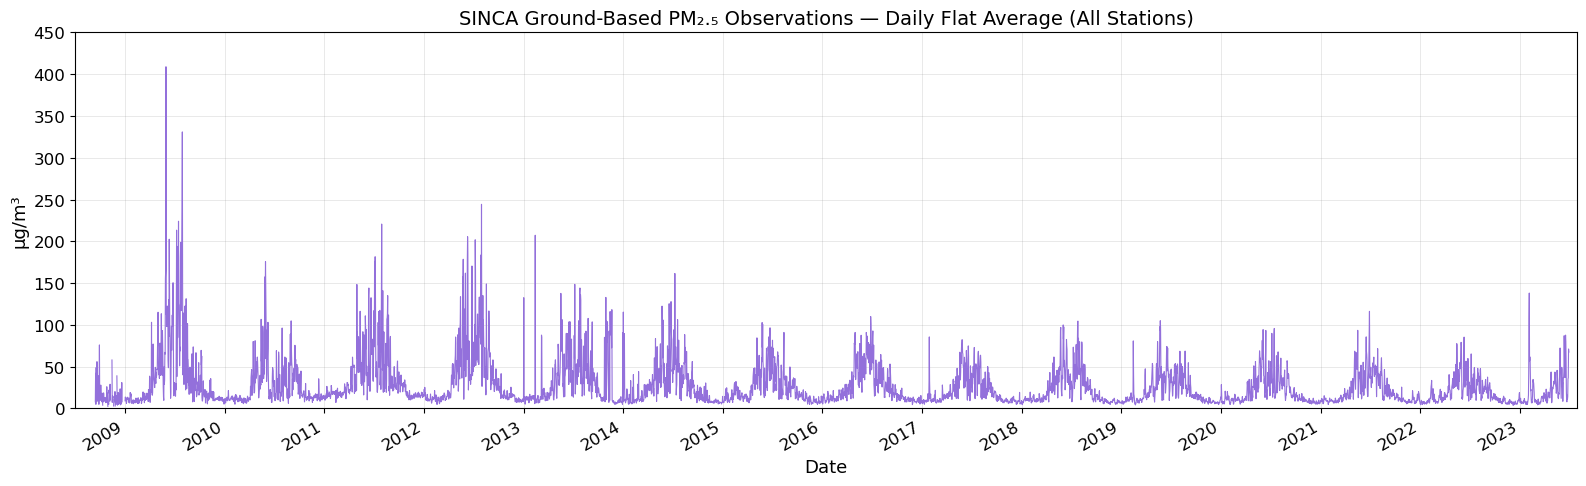

In [7]:
# Flat Average (all stations have equal weight)
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

overall_flat_daily = (
    daily_station
    .groupby("date_only")["PM25"]
    .mean()
    .reset_index()
    .rename(columns={"PM25": "PM25_flat_mean"})
    .sort_values("date_only")
)
overall_flat_daily["date_only"] = pd.to_datetime(overall_flat_daily["date_only"])
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(overall_flat_daily["date_only"], overall_flat_daily["PM25_flat_mean"],
        linewidth=0.8, color="mediumpurple")
ax.set_title("SINCA Ground-Based PM₂.₅ Observations — Daily Flat Average (All Stations)")
ax.set_ylabel("µg/m³")
ax.set_xlabel("Date")
ax.set_xlim(pd.Timestamp("2008-07-01"), pd.Timestamp("2023-07-30"))
ax.set_ylim(0, 450)  # excludes one anomalous single-station reading, 30 May 2009, outside fire season
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("../outputs/fig10_sinca_pm25_flat_timeseries.png", dpi=400, bbox_inches="tight")
plt.show()

In [8]:
overall_flat_daily[overall_flat_daily["PM25_flat_mean"].notna()]["date_only"].dt.year.value_counts().sort_index()

date_only
2004      2
2005      1
2006      1
2007      2
2008     86
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    181
Name: count, dtype: int64

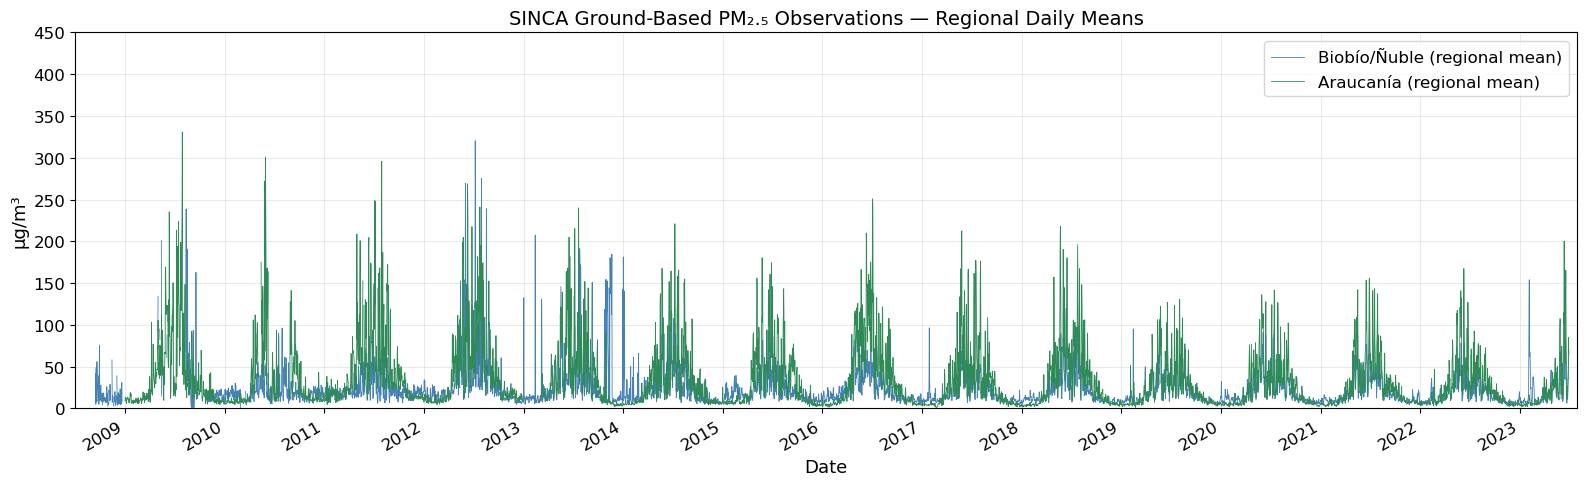

In [9]:
biobio_nuble_daily = daily_regional[daily_regional["region"] == "VIII"].sort_values("date_only")
araucania_daily = daily_regional[daily_regional["region"] == "IX"].sort_values("date_only")
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(biobio_nuble_daily["date_only"], biobio_nuble_daily["PM25_regional_mean"],
        linewidth=0.6, color="steelblue", label="Biobío/Ñuble (regional mean)")
ax.plot(araucania_daily["date_only"], araucania_daily["PM25_regional_mean"],
        linewidth=0.6, color="seagreen", label="Araucanía (regional mean)")
ax.set_title("SINCA Ground-Based PM₂.₅ Observations — Regional Daily Means")
ax.set_ylabel("µg/m³")
ax.set_xlabel("Date")
ax.set_xlim(pd.Timestamp("2008-07-01"), pd.Timestamp("2023-07-30"))
ax.set_ylim(0, 450) 
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("../outputs/fig11_sinca_pm25_regional_timeseries.png", dpi=400, bbox_inches="tight")
plt.show()

In [10]:
# check for the outlier
print("Flat average max:", overall_flat_daily["PM25_flat_mean"].max())
print("Biobío/Ñuble regional max:", biobio_nuble_daily["PM25_regional_mean"].max())
print("Araucanía regional max:", araucania_daily["PM25_regional_mean"].max())

# is the outlier just in one location or multiple
exact_date = biobio_nuble_daily.loc[biobio_nuble_daily["PM25_regional_mean"].idxmax(), "date_only"]
print(exact_date)

day_data = daily_station[(daily_station["date_only"] == exact_date.date()) & (daily_station["region"] == "VIII")]
print(day_data[["site", "PM25"]].dropna(subset=["PM25"]))

print(day_data)  # confirm the site code

Flat average max: 408.81028749999996
Biobío/Ñuble regional max: 968.0
Araucanía regional max: 330.8468764705882
2009-05-30 00:00:00
Empty DataFrame
Columns: [site, PM25]
Index: []
Empty DataFrame
Columns: [site, region, date_only, PM25]
Index: []


In [11]:
# Helper functions
def is_fire_season(date):
    return date.month in [11, 12, 1, 2, 3]

def assign_fire_year(date):
    if date.month >= 7:
        return date.year
    else:
        return date.year - 1

Fire year 2013 fire-season daily values:
 date_only  PM25_flat_mean
2013-11-01       79.141471
2013-11-02      103.302083
2013-11-03      103.135954
2013-11-04      103.741565
2013-11-05       57.058373
2013-11-06       40.321799
2013-11-07       29.532266
2013-11-08       18.785977
2013-11-09        7.364673
2013-11-10       92.534964
2013-11-11       81.700132
2013-11-12        9.611634
2013-11-13      115.531867
2013-11-14      115.994422
2013-11-15       88.058903
2013-11-16      100.931548
2013-11-17       97.352430
2013-11-18       99.357513
2013-11-19       72.603637
2013-11-20      118.225946
2013-11-21       10.429488
2013-11-22        8.861282
2013-11-23        9.316603
2013-11-24        7.352041
2013-11-25        7.791433
2013-11-26        9.252846
2013-11-27        8.417810
2013-11-28        6.168269
2013-11-29        6.351511
2013-11-30        7.498020
2013-12-01        4.962186
2013-12-02        6.680866
2013-12-03        7.693847
2013-12-04        6.770005
2013-12-05    

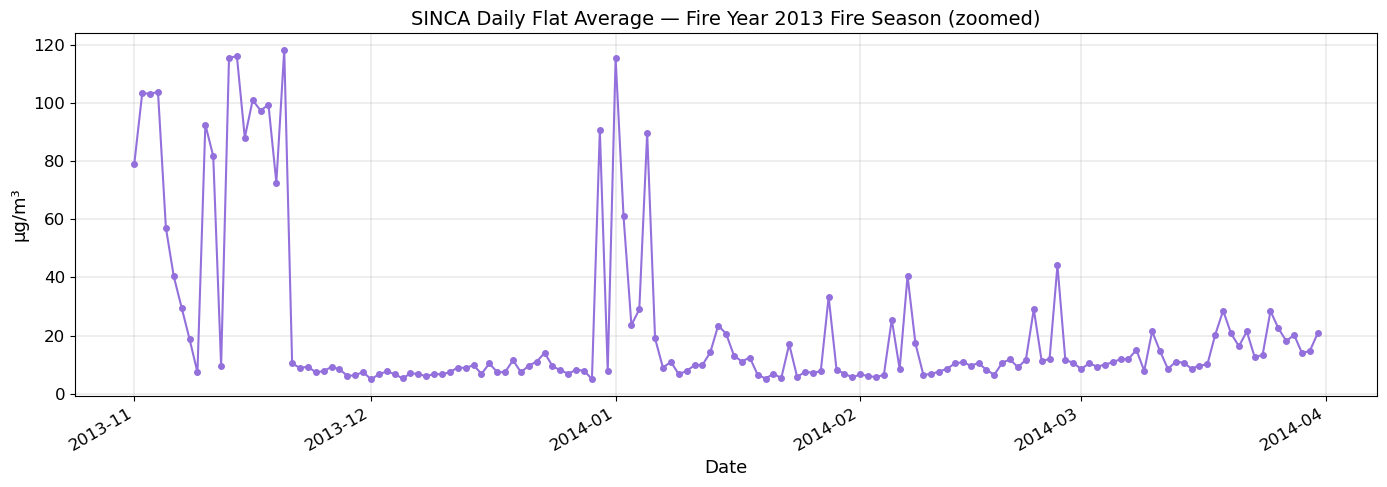

In [12]:
# Investigating the 2013/14 fire year spike 
overall_flat_daily["fire_year"] = overall_flat_daily["date_only"].apply(assign_fire_year)
overall_flat_daily["fire_season"] = overall_flat_daily["date_only"].apply(is_fire_season)

target_fire_year = 2013

# All daily values within this fire year's fire season (Nov-Mar)
fy_data = overall_flat_daily[
    (overall_flat_daily["fire_year"] == target_fire_year) &
    (overall_flat_daily["fire_season"])
].sort_values("date_only")

print(f"Fire year {target_fire_year} fire-season daily values:")
print(fy_data[["date_only", "PM25_flat_mean"]].to_string(index=False))

# How many valid days actually exist this fire year (data density check)
valid_days = fy_data["PM25_flat_mean"].notna().sum()
total_days = len(fy_data)
print(f"\n{valid_days} of {total_days} fire-season days have data")

# Sorted by value, to see the top days driving the mean/p95
print(f"\nTop 10 highest days in fire year {target_fire_year}:")
top_days = fy_data.dropna(subset=["PM25_flat_mean"]).sort_values("PM25_flat_mean", ascending=False)
print(top_days[["date_only", "PM25_flat_mean"]].head(10).to_string(index=False))

# Station-level detail for the single highest day
if len(top_days) > 0:
    peak_date = top_days.iloc[0]["date_only"]
    peak_stations = daily_station[daily_station["date_only"] == peak_date]
    peak_stations = peak_stations[peak_stations["PM25"].notna()]
    print(f"\nStation-level detail for peak day ({peak_date.date()}):")
    print(peak_stations[["site", "region", "PM25"]].to_string(index=False))

# How many stations contributed on each of the top 10 days (thin-sample check)
print(f"\nStation count per top day:")
for _, row in top_days.head(10).iterrows():
    d = row["date_only"]
    n_stations = daily_station[(daily_station["date_only"] == d) & (daily_station["PM25"].notna())].shape[0]
    print(f"{d.date()}: PM2.5={row['PM25_flat_mean']:.1f}, {n_stations} station(s) reporting")

# Compare to a "normal" year for context (e.g. the year before)
comparison_year = target_fire_year - 1
fy_compare = overall_flat_daily[
    (overall_flat_daily["fire_year"] == comparison_year) &
    (overall_flat_daily["fire_season"])
]
print(f"\nFor comparison, fire year {comparison_year} fire-season stats:")
print(f"Mean: {fy_compare['PM25_flat_mean'].mean():.2f}, Max: {fy_compare['PM25_flat_mean'].max():.2f}, "
      f"Valid days: {fy_compare['PM25_flat_mean'].notna().sum()}")

# Zoomed-in plot just for this fire year, to see the spike clearly at proper resolution
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fy_data["date_only"], fy_data["PM25_flat_mean"], marker="o", markersize=4, color="mediumpurple")
ax.set_title(f"SINCA Daily Flat Average — Fire Year {target_fire_year} Fire Season (zoomed)")
ax.set_ylabel("µg/m³")
ax.set_xlabel("Date")
ax.grid(True, linewidth=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [13]:
# Compare distribution shape across multiple fire years 
years_to_compare = [2010, 2012, 2013, 2016]

for yr in years_to_compare:
    fy_data = overall_flat_daily[(overall_flat_daily["fire_year"] == yr) & (overall_flat_daily["fire_season"])]
    print(f"\n=== Fire year {yr} ===")
    print(fy_data["PM25_flat_mean"].describe())

print("\n--- Threshold day counts ---")
threshold_results = []
for yr in years_to_compare:
    fy_data = overall_flat_daily[(overall_flat_daily["fire_year"] == yr) & (overall_flat_daily["fire_season"])]
    row = {"fire_year": yr, "valid_days": fy_data["PM25_flat_mean"].notna().sum(),
           "max_day": fy_data["PM25_flat_mean"].max()}
    for threshold in [20, 30, 50, 100]:
        row[f">{threshold}"] = (fy_data["PM25_flat_mean"] > threshold).sum()
    threshold_results.append(row)

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))


=== Fire year 2010 ===
count    151.000000
mean      16.404770
std        5.081843
min        7.173837
25%       12.808106
50%       15.739805
75%       19.182004
max       35.491573
Name: PM25_flat_mean, dtype: float64

=== Fire year 2012 ===
count    151.000000
mean      15.481031
std       20.642235
min        5.211319
25%        9.884155
50%       12.337464
75%       14.680025
max      207.231427
Name: PM25_flat_mean, dtype: float64

=== Fire year 2013 ===
count    151.000000
mean      22.403280
std       28.804617
min        4.962186
25%        7.571346
50%       10.414827
75%       20.275215
max      118.225946
Name: PM25_flat_mean, dtype: float64

=== Fire year 2016 ===
count    151.000000
mean      11.148720
std        7.453982
min        4.634353
25%        7.990761
50%        9.563814
75%       11.881985
max       85.602446
Name: PM25_flat_mean, dtype: float64

--- Threshold day counts ---
 fire_year  valid_days    max_day  >20  >30  >50  >100
      2010         151  35.4915

In [14]:
# Trend analysis: flat average (all stations, equal weight) 
overall_flat_daily["fire_season"] = overall_flat_daily["date_only"].apply(is_fire_season)
overall_flat_daily["fire_year"] = overall_flat_daily["date_only"].apply(assign_fire_year)

sinca_annual_flat = (
    overall_flat_daily[overall_flat_daily["fire_season"]]
    .groupby("fire_year")
    .agg(SINCA_flat_mean=("PM25_flat_mean", "mean"),
         SINCA_flat_p95=("PM25_flat_mean", lambda x: x.quantile(0.95)))
    .reset_index()
)
sinca_flat_valid = sinca_annual_flat.dropna(subset=["SINCA_flat_mean"])

mk_flat_mean = mk.original_test(sinca_flat_valid["SINCA_flat_mean"])
mk_flat_p95 = mk.original_test(sinca_flat_valid["SINCA_flat_p95"])

print("=== Flat average (all stations) ===")
print(sinca_flat_valid)
print(f"Mean trend: p={mk_flat_mean.p:.4f}, slope={mk_flat_mean.slope:.4f}, trend={mk_flat_mean.trend}")
print(f"P95 trend:  p={mk_flat_p95.p:.4f}, slope={mk_flat_p95.slope:.4f}, trend={mk_flat_p95.trend}")

# Trend analysis: regional means 
biobio_nuble_daily = daily_regional[daily_regional["region"] == "VIII"].copy()
araucania_daily = daily_regional[daily_regional["region"] == "IX"].copy()

biobio_nuble_daily["fire_season"] = biobio_nuble_daily["date_only"].apply(is_fire_season)
biobio_nuble_daily["fire_year"] = biobio_nuble_daily["date_only"].apply(assign_fire_year)
araucania_daily["fire_season"] = araucania_daily["date_only"].apply(is_fire_season)
araucania_daily["fire_year"] = araucania_daily["date_only"].apply(assign_fire_year)

biobio_annual = (
    biobio_nuble_daily[biobio_nuble_daily["fire_season"]]
    .groupby("fire_year")
    .agg(SINCA_mean=("PM25_regional_mean", "mean"),
         SINCA_p95=("PM25_regional_mean", lambda x: x.quantile(0.95)))
    .reset_index()
    .dropna(subset=["SINCA_mean"])
)
araucania_annual = (
    araucania_daily[araucania_daily["fire_season"]]
    .groupby("fire_year")
    .agg(SINCA_mean=("PM25_regional_mean", "mean"),
         SINCA_p95=("PM25_regional_mean", lambda x: x.quantile(0.95)))
    .reset_index()
    .dropna(subset=["SINCA_mean"])
)

mk_biobio_mean = mk.original_test(biobio_annual["SINCA_mean"])
mk_biobio_p95 = mk.original_test(biobio_annual["SINCA_p95"])
mk_arauc_mean = mk.original_test(araucania_annual["SINCA_mean"])
mk_arauc_p95 = mk.original_test(araucania_annual["SINCA_p95"])

print("\n=== Biobío/Ñuble ===")
print(biobio_annual)
print(f"Mean trend: p={mk_biobio_mean.p:.4f}, slope={mk_biobio_mean.slope:.4f}, trend={mk_biobio_mean.trend}")
print(f"P95 trend:  p={mk_biobio_p95.p:.4f}, slope={mk_biobio_p95.slope:.4f}, trend={mk_biobio_p95.trend}")

print("\n=== Araucanía ===")
print(araucania_annual)
print(f"Mean trend: p={mk_arauc_mean.p:.4f}, slope={mk_arauc_mean.slope:.4f}, trend={mk_arauc_mean.trend}")
print(f"P95 trend:  p={mk_arauc_p95.p:.4f}, slope={mk_arauc_p95.slope:.4f}, trend={mk_arauc_p95.trend}")

=== Flat average (all stations) ===
    fire_year  SINCA_flat_mean  SINCA_flat_p95
2        2004         7.166667       11.516667
3        2005         1.000000        1.000000
4        2006        22.000000       22.000000
6        2008        12.034820       22.393744
7        2009        11.645809       17.721492
8        2010        16.404770       26.934363
9        2011        13.555393       19.187896
10       2012        15.481031       20.997151
11       2013        22.403280      100.144531
12       2014        12.263825       24.308353
13       2015        11.794260       21.557043
14       2016        11.148720       17.428185
15       2017        10.027964       14.889802
16       2018        10.494979       17.418558
17       2019         9.532378       15.418084
18       2020         9.214889       14.257830
19       2021        10.547413       20.863119
20       2022        12.391586       33.616932
Mean trend: p=0.3247, slope=-0.2230, trend=no trend
P95 trend:  p=1.000

In [15]:
# Trend analysis: flat average, starting in 2008/09 
sinca_flat_valid_2008on = sinca_flat_valid[sinca_flat_valid["fire_year"] >= 2008]

print("=== Flat average (all stations), fire year 2008 onwards ===")
print(sinca_flat_valid_2008on)

mk_flat_mean_2008on = mk.original_test(sinca_flat_valid_2008on["SINCA_flat_mean"])
mk_flat_p95_2008on = mk.original_test(sinca_flat_valid_2008on["SINCA_flat_p95"])

print(f"Mean trend (2008 onwards): p={mk_flat_mean_2008on.p:.4f}, slope={mk_flat_mean_2008on.slope:.4f}, trend={mk_flat_mean_2008on.trend}")
print(f"P95 trend (2008 onwards):  p={mk_flat_p95_2008on.p:.4f}, slope={mk_flat_p95_2008on.slope:.4f}, trend={mk_flat_p95_2008on.trend}")

=== Flat average (all stations), fire year 2008 onwards ===
    fire_year  SINCA_flat_mean  SINCA_flat_p95
6        2008        12.034820       22.393744
7        2009        11.645809       17.721492
8        2010        16.404770       26.934363
9        2011        13.555393       19.187896
10       2012        15.481031       20.997151
11       2013        22.403280      100.144531
12       2014        12.263825       24.308353
13       2015        11.794260       21.557043
14       2016        11.148720       17.428185
15       2017        10.027964       14.889802
16       2018        10.494979       17.418558
17       2019         9.532378       15.418084
18       2020         9.214889       14.257830
19       2021        10.547413       20.863119
20       2022        12.391586       33.616932
Mean trend (2008 onwards): p=0.0294, slope=-0.3269, trend=decreasing
P95 trend (2008 onwards):  p=0.1982, slope=-0.3540, trend=no trend


In [16]:
# Check whether valid day count varies meaningfully across fire years (2008 onwards)
valid_day_counts = (
    overall_flat_daily[overall_flat_daily["fire_season"] & (overall_flat_daily["fire_year"] >= 2008)]
    .dropna(subset=["PM25_flat_mean"])
    .groupby("fire_year")
    .size()
)
print(valid_day_counts)

# quick correlation check: does day count itself correlate with year? (would suggest a systematic drift)
from scipy import stats as sp_stats
years = valid_day_counts.index.values
counts = valid_day_counts.values
corr = sp_stats.pearsonr(years, counts)
print(f"\nCorrelation between fire year and valid day count: r={corr[0]:.3f}, p={corr[1]:.4f}")

fire_year
2008    129
2009    151
2010    151
2011    152
2012    151
2013    151
2014    151
2015    152
2016    151
2017    151
2018    151
2019    152
2020    151
2021    151
2022    151
dtype: int64

Correlation between fire year and valid day count: r=0.428, p=0.1117


### Inspecting the Dip in the Trend in 2005/6

In [17]:
# Which calendar days actually have data in this window?
window = overall_flat_daily[
    (overall_flat_daily["date_only"] >= pd.Timestamp("2004-07-01")) &
    (overall_flat_daily["date_only"] <= pd.Timestamp("2007-06-30"))
]
print(window[window["PM25_flat_mean"].notna()][["date_only", "PM25_flat_mean", "fire_year"]])

# Which station(s) actually contributed on those specific valid days?
valid_dates = window[window["PM25_flat_mean"].notna()]["date_only"].tolist()

# ensure daily_station's date_only is also a proper datetime for comparison
daily_station["date_only"] = pd.to_datetime(daily_station["date_only"])

for d in valid_dates:
    day_data = daily_station[daily_station["date_only"] == d]
    contributing = day_data[day_data["PM25"].notna()]
    print(f"\n{d.date()}: {len(contributing)} station(s) reporting")
    print(contributing[["site", "region", "PM25"]])

# How many stations existed in this window at all
coverage_check = (
    daily_station[
        (daily_station["date_only"] >= pd.Timestamp("2004-07-01")) &
        (daily_station["date_only"] <= pd.Timestamp("2007-06-30"))
    ]
    .groupby("date_only")["PM25"]
    .apply(lambda x: x.notna().sum())
)
print("\nDays with at least one station reporting PM2.5 (2004-07 to 2007-06):")
print(coverage_check[coverage_check > 0])

      date_only  PM25_flat_mean  fire_year
892  2004-12-09    2.333333e+00       2004
893  2004-12-10    1.200000e+01       2004
1271 2005-12-23    1.000000e+00       2005
1461 2006-07-01    2.242080e-44       2006
1650 2007-01-06    2.200000e+01       2006

2004-12-09: 3 station(s) reporting
        site region  PM25
85262    CNH   VIII   0.0
277012  THNI   VIII   0.0
323032   TME   VIII   7.0

2004-12-10: 1 station(s) reporting
       site region  PM25
323033  TME   VIII  12.0

2005-12-23: 1 station(s) reporting
      site region  PM25
85641  CNH   VIII   1.0

2006-07-01: 1 station(s) reporting
      site region          PM25
85831  CNH   VIII  2.242080e-44

2007-01-06: 1 station(s) reporting
       site region  PM25
323790  TME   VIII  22.0

Days with at least one station reporting PM2.5 (2004-07 to 2007-06):
date_only
2004-12-09    3
2004-12-10    1
2005-12-23    1
2006-07-01    1
2007-01-06    1
Name: PM25, dtype: int64


### Number of Stations in Each Region to Further My Understanding

In [18]:
# Number of stations over the years in each region
station_counts_by_year = (
    daily_station
    .dropna(subset=["PM25"])
    .assign(fire_year=lambda d: pd.to_datetime(d["date_only"]).apply(assign_fire_year))
    .groupby(["region", "fire_year"])["site"]
    .nunique()
    .reset_index(name="station_count")
)

biobio_station_counts = station_counts_by_year[station_counts_by_year["region"] == "VIII"]
araucania_station_counts = station_counts_by_year[station_counts_by_year["region"] == "IX"]

print("Biobío/Ñuble station counts by fire year:")
print(biobio_station_counts.to_string(index=False))

print("\nAraucanía station counts by fire year:")
print(araucania_station_counts.to_string(index=False))

Biobío/Ñuble station counts by fire year:
region  fire_year  station_count
  VIII       2004              3
  VIII       2005              1
  VIII       2006              2
  VIII       2007              1
  VIII       2008              2
  VIII       2009              5
  VIII       2010              1
  VIII       2011              7
  VIII       2012              8
  VIII       2013              8
  VIII       2014              9
  VIII       2015             15
  VIII       2016             18
  VIII       2017             18
  VIII       2018             20
  VIII       2019             21
  VIII       2020             25
  VIII       2021             25
  VIII       2022             26

Araucanía station counts by fire year:
region  fire_year  station_count
    IX       2008              2
    IX       2009              2
    IX       2010              2
    IX       2011              3
    IX       2012              3
    IX       2013              3
    IX       2014          

## Set Up Comparisons

In [19]:
MIN_FIRE_YEAR = 2008

sinca_annual_flat = sinca_annual_flat[sinca_annual_flat["fire_year"] >= MIN_FIRE_YEAR].reset_index(drop=True)

print(sinca_annual_flat)

    fire_year  SINCA_flat_mean  SINCA_flat_p95
0        2008        12.034820       22.393744
1        2009        11.645809       17.721492
2        2010        16.404770       26.934363
3        2011        13.555393       19.187896
4        2012        15.481031       20.997151
5        2013        22.403280      100.144531
6        2014        12.263825       24.308353
7        2015        11.794260       21.557043
8        2016        11.148720       17.428185
9        2017        10.027964       14.889802
10       2018        10.494979       17.418558
11       2019         9.532378       15.418084
12       2020         9.214889       14.257830
13       2021        10.547413       20.863119
14       2022        12.391586       33.616932


In [20]:
# Load FSL and GFAS annual data
method1 = pd.read_csv("../outputs/method1_results.csv")
method2 = pd.read_csv("../outputs/method2_results.csv")
method3 = pd.read_csv("../outputs/method3_percell_results.csv")
gfas_annual = pd.read_csv("../outputs/gfas_pm25_annual_totals.csv")

method1["fire_year"] = pd.to_datetime(method1["fire_year_start"]).dt.year
method2["fire_year"] = pd.to_datetime(method2["fire_year_start"]).dt.year
method3["fire_year"] = method3["fire_year"].str.split("-").str[0].astype(int)
gfas_annual = gfas_annual.rename(columns={"fire_year_start": "fire_year"})

# Load GFAS daily (for climatology)
gfas_daily = pd.read_csv("../outputs/gfas_pm25_daily_totals.csv")
gfas_daily["date_only"] = pd.to_datetime(gfas_daily["date"])
gfas_daily["month"] = gfas_daily["date_only"].dt.month

# Load FINN whole-study-area daily data, build annual series (full fire-year, no season restriction)
finn_daily_full = pd.read_csv("../outputs/finn_pm25_daily_core.csv")
finn_daily_full["date_only"] = pd.to_datetime(finn_daily_full["date"])
finn_daily_full["fire_season"] = finn_daily_full["date_only"].apply(is_fire_season)
finn_daily_full["fire_year"] = finn_daily_full["date_only"].apply(assign_fire_year)
finn_daily_full["month"] = finn_daily_full["date_only"].dt.month

finn_annual_overall = (
    finn_daily_full
    .groupby("fire_year")
    .agg(FINN_sum=("PM25_kg_day_sum", "sum"))
    .reset_index()
)

# Build the master comparison table
comparison = sinca_annual_flat.rename(columns={"SINCA_flat_mean": "SINCA_mean", "SINCA_flat_p95": "SINCA_p95"})
comparison = comparison.merge(
    method1[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method1_length"}),
    on="fire_year", how="outer")
comparison = comparison.merge(
    method2[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method2_length"}),
    on="fire_year", how="outer")
comparison = comparison.merge(method3[["fire_year", "fsl_p90_median"]], on="fire_year", how="outer")
comparison = comparison.merge(gfas_annual, on="fire_year", how="outer")
comparison = comparison.merge(finn_annual_overall, on="fire_year", how="outer")

comparison = comparison.sort_values("fire_year").reset_index(drop=True)
print(comparison)

    fire_year  SINCA_mean   SINCA_p95  method1_length  method2_length  \
0        2002         NaN         NaN             326              98   
1        2003         NaN         NaN             280              71   
2        2004         NaN         NaN             279              90   
3        2005         NaN         NaN             294             157   
4        2006         NaN         NaN             260              29   
5        2007         NaN         NaN             288              88   
6        2008   12.034820   22.393744             236              95   
7        2009   11.645809   17.721492             263              84   
8        2010   16.404770   26.934363             300             111   
9        2011   13.555393   19.187896             241              50   
10       2012   15.481031   20.997151             314             224   
11       2013   22.403280  100.144531             285              68   
12       2014   12.263825   24.308353             3

In [21]:
# Reusable comparison function
def compare_to_sinca(comparison_df, other_col, other_label, other_units,
                      sinca_col="SINCA_mean", sinca_label="SINCA mean",
                      fire_year_col="fire_year", save_prefix=None, ax=None,
                      min_fire_year=2008):
    color_map = {
        "FINN": "firebrick",
        "GFAS": "crimson",
        "METHOD1": "#5B7FBF",
        "METHOD2": "#F77F00",
        "METHOD3": "#43AA8B",
    }
    sinca_color = "mediumpurple"
    other_color = "dimgrey"  # fallback default
    for key, color in color_map.items():
        if key.upper() in other_label.upper().replace(" ", ""):
            other_color = color
            break

    # exclude fire years before 2008/09 entirely - pre-2008 SINCA coverage is too sparse to be reliable
    comparison_df = comparison_df[comparison_df[fire_year_col] >= min_fire_year].copy()

    # check for years where SINCA data is missing (e.g. insufficient station reporting) within the retained range
    missing_sinca_years = comparison_df[comparison_df[sinca_col].isna()][fire_year_col].tolist()
    paired = comparison_df.dropna(subset=[sinca_col, other_col]).copy()
    n = len(paired)
    print(f"=== SINCA vs {other_label} (n={n} years, fire year {min_fire_year} onwards) ===")
    mk_sinca = mk.original_test(paired[sinca_col])
    mk_other = mk.original_test(paired[other_col])
    print(f"{sinca_label} trend: p={mk_sinca.p:.4f}, slope={mk_sinca.slope:.4g}, trend={mk_sinca.trend}")
    print(f"{other_label} trend: p={mk_other.p:.4f}, slope={mk_other.slope:.4g}, trend={mk_other.trend}")
    pear = stats.pearsonr(paired[sinca_col], paired[other_col])
    spear = stats.spearmanr(paired[sinca_col], paired[other_col])
    print(f"Pearson r={pear[0]:.3f} (p={pear[1]:.4f}), Spearman r={spear[0]:.3f} (p={spear[1]:.4f})")
    paired["sinca_z"] = (paired[sinca_col] - paired[sinca_col].mean()) / paired[sinca_col].std()
    paired["other_z"] = (paired[other_col] - paired[other_col].mean()) / paired[other_col].std()
    anomalies = paired[(paired["sinca_z"].abs() > 1.5) | (paired["other_z"].abs() > 1.5)]
    print(f"Anomaly years: {anomalies[fire_year_col].tolist()}")

    standalone = ax is None
    if standalone:
        fig, ax1 = plt.subplots(figsize=(14, 5))
    else:
        ax1 = ax
        fig = ax1.figure

    ax2 = ax1.twinx()
    ax1.plot(paired[fire_year_col], paired[sinca_col], color=sinca_color, marker="o", label=sinca_label)
    ax2.plot(paired[fire_year_col], paired[other_col], color=other_color, marker="s", label=other_label)
    ax1.set_ylabel(f"{sinca_label} (µg/m³)", color=sinca_color)
    ax2.set_ylabel(f"{other_label} ({other_units})", color=other_color)
    ax1.set_xlabel("Fire year")
    ax1.set_title(f"SINCA vs {other_label}")
    x_min, x_max = paired[fire_year_col].min(), paired[fire_year_col].max()
    in_range_missing = [y for y in missing_sinca_years if x_min <= y <= x_max]
    all_tick_years = sorted(set(paired[fire_year_col].tolist()) | set(in_range_missing))
    ax1.set_xticks(all_tick_years)
    ax1.set_xticklabels([f"{int(y)}-{int(y)+1}" for y in all_tick_years])
    ax1.tick_params(axis="x", rotation=75)
    for year in in_range_missing:
        ax1.axvline(year, color="grey", linestyle="--", linewidth=1, alpha=0.5)
    ax1.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax1.set_axisbelow(True)

    if standalone:
        fig.tight_layout()
        if save_prefix:
            plt.savefig(f"../outputs/{save_prefix}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return {"label": other_label, "n": n, "mk_sinca": mk_sinca, "mk_other": mk_other,
            "pearson": pear, "spearman": spear, "anomaly_years": anomalies[fire_year_col].tolist(),
            "missing_sinca_years": missing_sinca_years, "paired_df": paired}

## SINCA & FINN

In [22]:
for name in ["method1", "method2", "method3", "gfas_annual", "finn_annual_overall"]:
    print(name, name in dir())

method1 True
method2 True
method3 True
gfas_annual True
finn_annual_overall True


=== SINCA vs FINN (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
FINN trend: p=0.0175, slope=3.575e+06, trend=increasing
Pearson r=-0.123 (p=0.6624), Spearman r=-0.282 (p=0.3083)
Anomaly years: [2013, 2022]


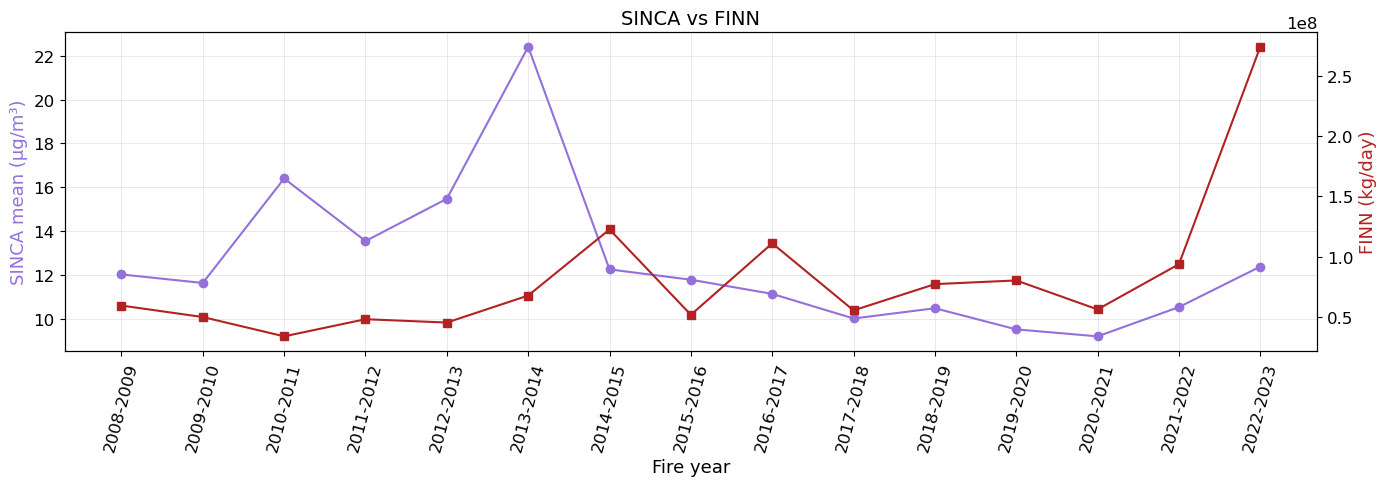

In [23]:
# SINCA vs FINN (whole study area)
results_finn_whole = compare_to_sinca(comparison, "FINN_sum", "FINN", "kg/day",
                                        save_prefix="fig12_sinca_vs_finn_whole")

=== SINCA vs FINN (Biobío/Ñuble) (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0030, slope=-0.5136, trend=decreasing
FINN (Biobío/Ñuble) trend: p=0.0377, slope=1.604e+06, trend=increasing
Pearson r=-0.125 (p=0.6563), Spearman r=-0.289 (p=0.2957)
Anomaly years: [2013, 2022]


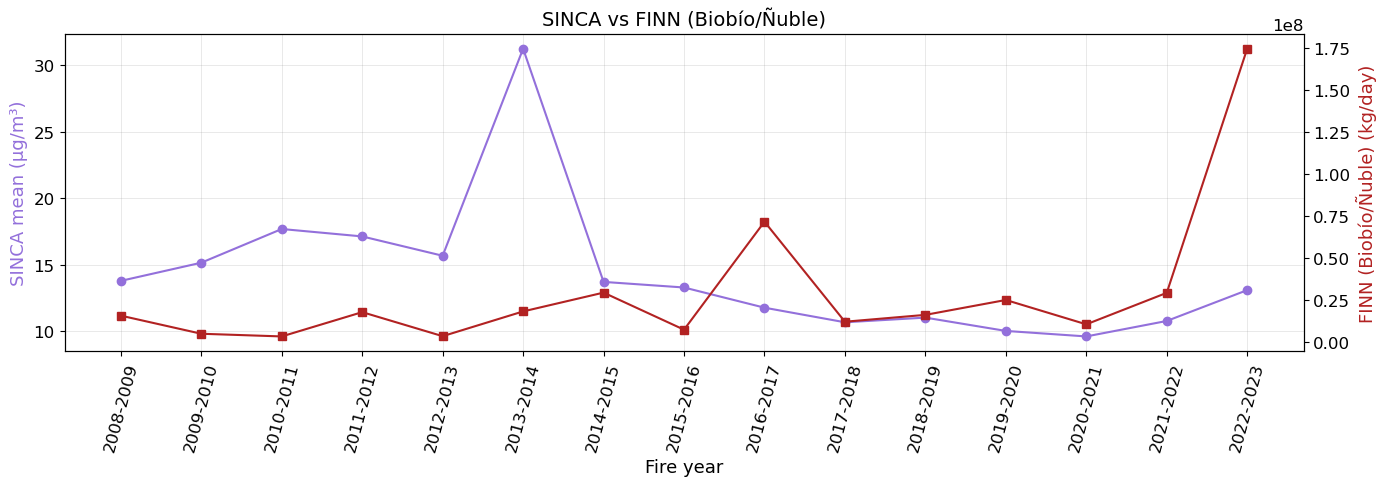

=== SINCA vs FINN (Araucanía) (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0041, slope=-0.3722, trend=decreasing
FINN (Araucanía) trend: p=0.0022, slope=1.974e+06, trend=increasing
Pearson r=-0.438 (p=0.1028), Spearman r=-0.571 (p=0.0261)
Anomaly years: [2010, 2012, 2014, 2022]


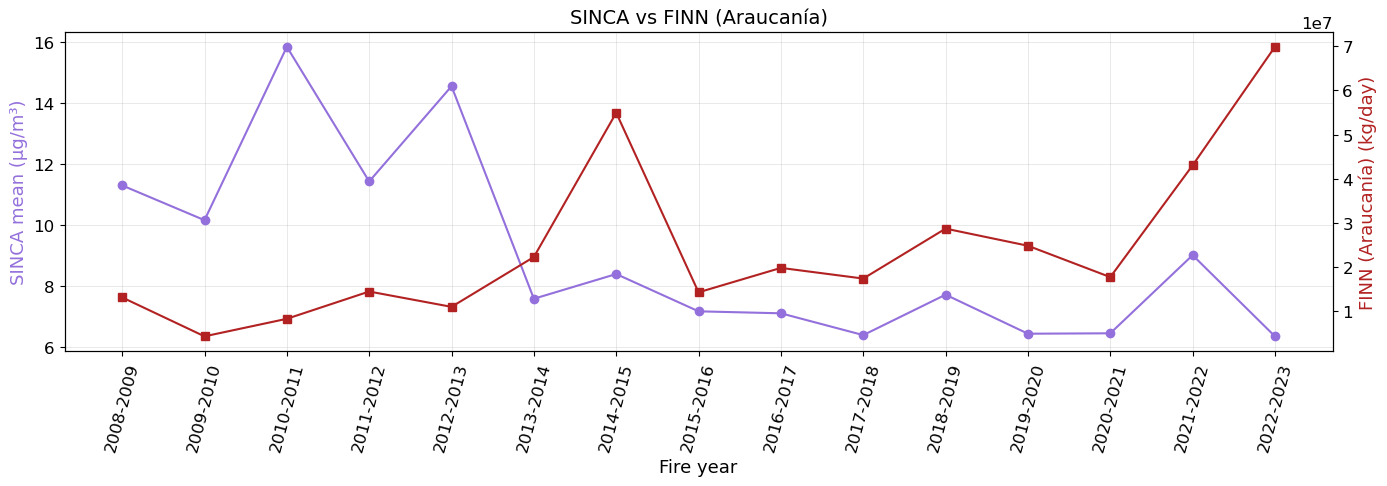

In [24]:
# SINCA vs FINN (regional supplementary comparisons)
finn_regional = pd.read_csv("../disdata/sinca_finn_comparison/finn_daily_regional.csv")
finn_regional["date_only"] = pd.to_datetime(finn_regional["date_only"])

merged_regional = pd.merge(daily_regional, finn_regional, on=["region", "date_only"], how="inner")
merged_regional["fire_season"] = merged_regional["date_only"].apply(is_fire_season)
merged_regional["fire_year"] = merged_regional["date_only"].apply(assign_fire_year)

biobio_annual = merged_regional[(merged_regional["region"] == "VIII") & (merged_regional["fire_season"])].groupby("fire_year").agg(
    SINCA_mean=("PM25_regional_mean", "mean"),
    SINCA_p95=("PM25_regional_mean", lambda x: x.quantile(0.95)),
    FINN_sum=("PM25_kg_day_sum", "sum")
).reset_index()

araucania_annual = merged_regional[(merged_regional["region"] == "IX") & (merged_regional["fire_season"])].groupby("fire_year").agg(
    SINCA_mean=("PM25_regional_mean", "mean"),
    SINCA_p95=("PM25_regional_mean", lambda x: x.quantile(0.95)),
    FINN_sum=("PM25_kg_day_sum", "sum")
).reset_index()

results_finn_biobio = compare_to_sinca(biobio_annual, "FINN_sum", "FINN (Biobío/Ñuble)", "kg/day",
                                         save_prefix="fig13_sinca_vs_finn_biobio")
results_finn_araucania = compare_to_sinca(araucania_annual, "FINN_sum", "FINN (Araucanía)", "kg/day",
                                            save_prefix="fig14_sinca_vs_finn_araucania")

## SINCA & GFAS

=== SINCA vs GFAS (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
GFAS trend: p=0.4884, slope=2.441e+05, trend=no trend
Pearson r=-0.038 (p=0.8921), Spearman r=0.229 (p=0.4126)
Anomaly years: [2013, 2022]


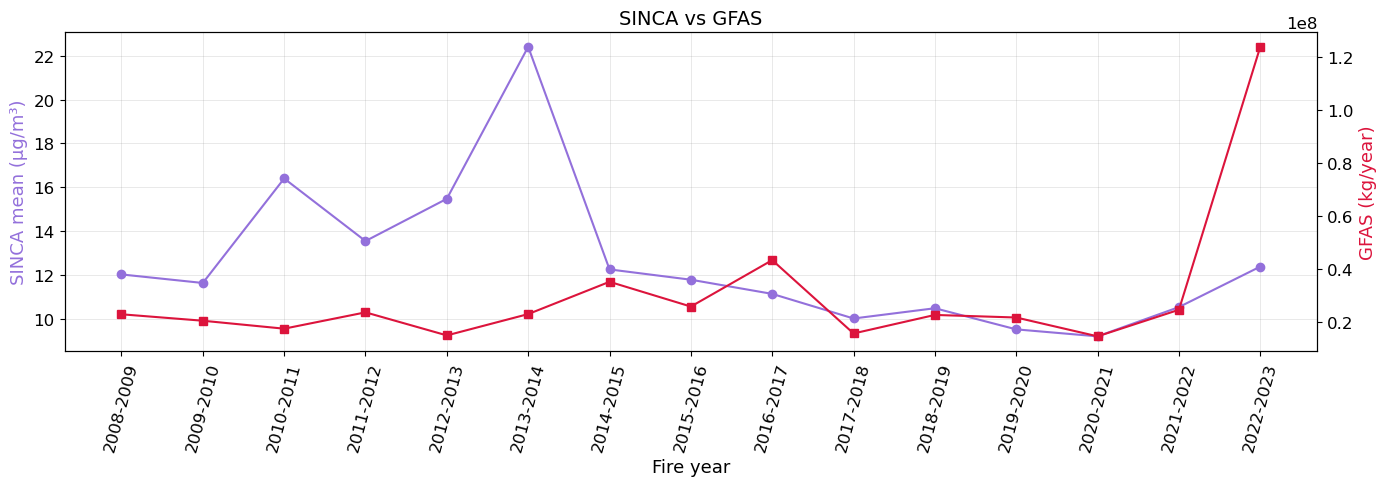

In [25]:
# SINCA vs GFAS
results_gfas = compare_to_sinca(comparison, "pm25_kg_total", "GFAS", "kg/year",
                                  save_prefix="fig_sinca_vs_gfas")

## SINCA & FSL

=== SINCA vs Method 1 (first–last fire date) (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
Method 1 (first–last fire date) trend: p=0.0115, slope=6.571, trend=increasing
Pearson r=-0.390 (p=0.1505), Spearman r=-0.593 (p=0.0197)
Anomaly years: [2008, 2011, 2013, 2017]
=== SINCA vs Method 2 (5th–95th pct burned area) (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
Method 2 (5th–95th pct burned area) trend: p=0.5526, slope=-1.429, trend=no trend
Pearson r=0.130 (p=0.6453), Spearman r=-0.061 (p=0.8298)
Anomaly years: [2012, 2013, 2016]
=== SINCA vs Method 3 (FWI per-cell threshold) (n=15 years, fire year 2008 onwards) ===
SINCA mean trend: p=0.0294, slope=-0.3269, trend=decreasing
Method 3 (FWI per-cell threshold) trend: p=0.0331, slope=3.875, trend=increasing
Pearson r=-0.374 (p=0.1694), Spearman r=-0.320 (p=0.2450)
Anomaly years: [2013, 2019]


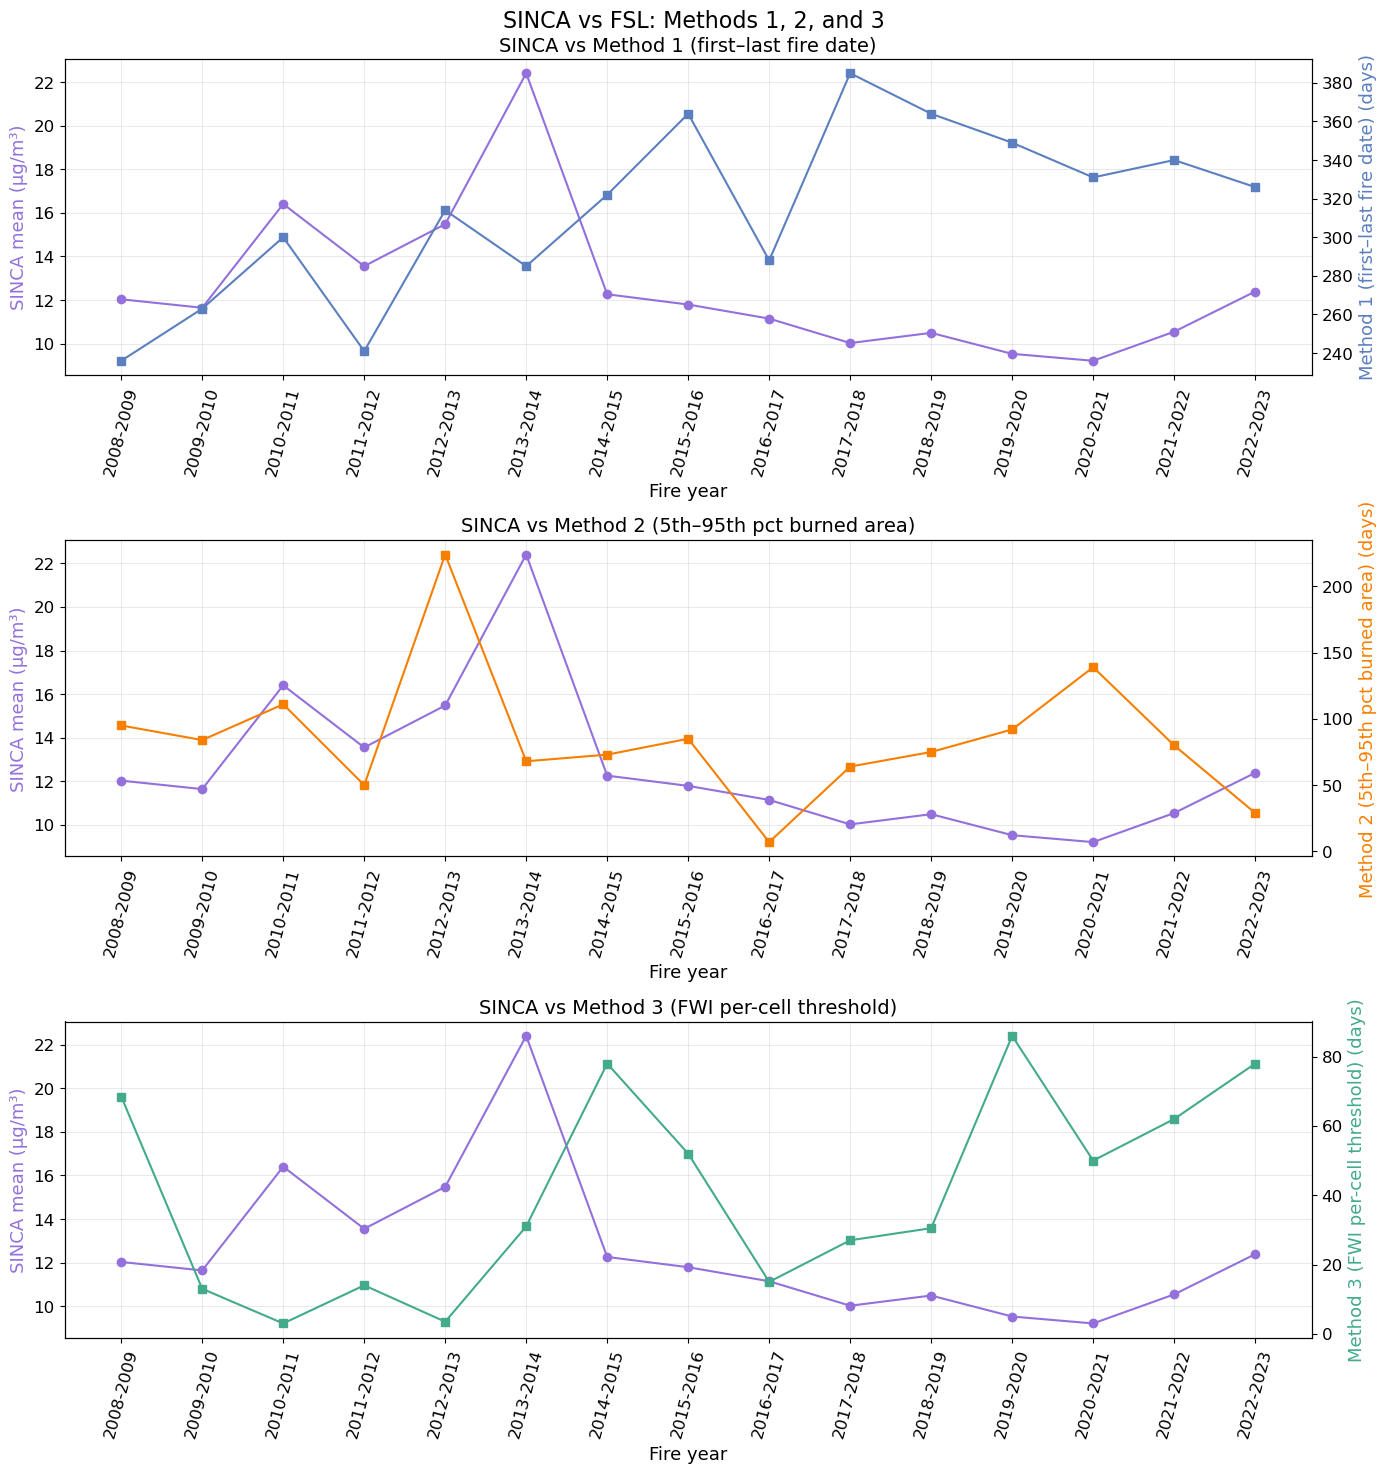

In [26]:
# All 3 FSL methods in one figure
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

results_fsl_m1 = compare_to_sinca(comparison, "method1_length", "Method 1 (first–last fire date)", "days",
                                    ax=axes[0])
results_fsl_m2 = compare_to_sinca(comparison, "method2_length", "Method 2 (5th–95th pct burned area)", "days",
                                    ax=axes[1])
results_fsl_m3 = compare_to_sinca(comparison, "fsl_p90_median", "Method 3 (FWI per-cell threshold)", "days",
                                    ax=axes[2])

fig.suptitle("SINCA vs FSL: Methods 1, 2, and 3", fontsize=16)
fig.tight_layout()
plt.savefig("../outputs/fig_sinca_vs_fsl_panel.png", dpi=400, bbox_inches="tight")
plt.show()

## SINCA v. FINN v. GFAS: 3-way trend and pairwise correlation

In [27]:
MIN_FIRE_YEAR = 2008

three_way = comparison[comparison["fire_year"] >= MIN_FIRE_YEAR].dropna(subset=["SINCA_mean", "FINN_sum", "pm25_kg_total"])
print(f"\nYears with all three data sources (fire year {MIN_FIRE_YEAR} onwards): {len(three_way)}")
print(three_way[["fire_year", "SINCA_mean", "FINN_sum", "pm25_kg_total"]])

for col, name in [("SINCA_mean", "SINCA"), ("FINN_sum", "FINN"), ("pm25_kg_total", "GFAS")]:
    result = mk.original_test(three_way[col])
    print(f"{name} trend: p={result.p:.4f}, slope={result.slope:.4g}, trend={result.trend}")

print("\nPairwise correlations (matched years only):")
pairs = [("SINCA_mean", "FINN_sum"), ("SINCA_mean", "pm25_kg_total"), ("FINN_sum", "pm25_kg_total")]
for a, b in pairs:
    pear = stats.pearsonr(three_way[a], three_way[b])
    spear = stats.spearmanr(three_way[a], three_way[b])
    print(f"{a} vs {b}: Pearson r={pear[0]:.3f} (p={pear[1]:.4f}), Spearman r={spear[0]:.3f} (p={spear[1]:.4f})")


Years with all three data sources (fire year 2008 onwards): 15
    fire_year  SINCA_mean      FINN_sum  pm25_kg_total
6        2008   12.034820  5.935283e+07   2.283347e+07
7        2009   11.645809  4.982733e+07   2.039989e+07
8        2010   16.404770  3.383082e+07   1.739813e+07
9        2011   13.555393  4.803868e+07   2.356574e+07
10       2012   15.481031  4.526063e+07   1.485922e+07
11       2013   22.403280  6.764825e+07   2.290983e+07
12       2014   12.263825  1.224394e+08   3.510075e+07
13       2015   11.794260  5.170794e+07   2.574919e+07
14       2016   11.148720  1.109344e+08   4.328219e+07
15       2017   10.027964  5.534614e+07   1.559331e+07
16       2018   10.494979  7.711576e+07   2.258700e+07
17       2019    9.532378  8.018314e+07   2.161700e+07
18       2020    9.214889  5.614855e+07   1.450513e+07
19       2021   10.547413  9.365570e+07   2.453972e+07
20       2022   12.391586  2.738536e+08   1.238241e+08
SINCA trend: p=0.0294, slope=-0.3269, trend=decreasing
F

## Seasonal Climatology Comparison

In [28]:
import matplotlib.ticker as mticker

month_labels = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

def use_sci_notation(ax, axis="y"):
    fmt = mticker.ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-3, 3))  # forces sci notation outside this exponent range
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

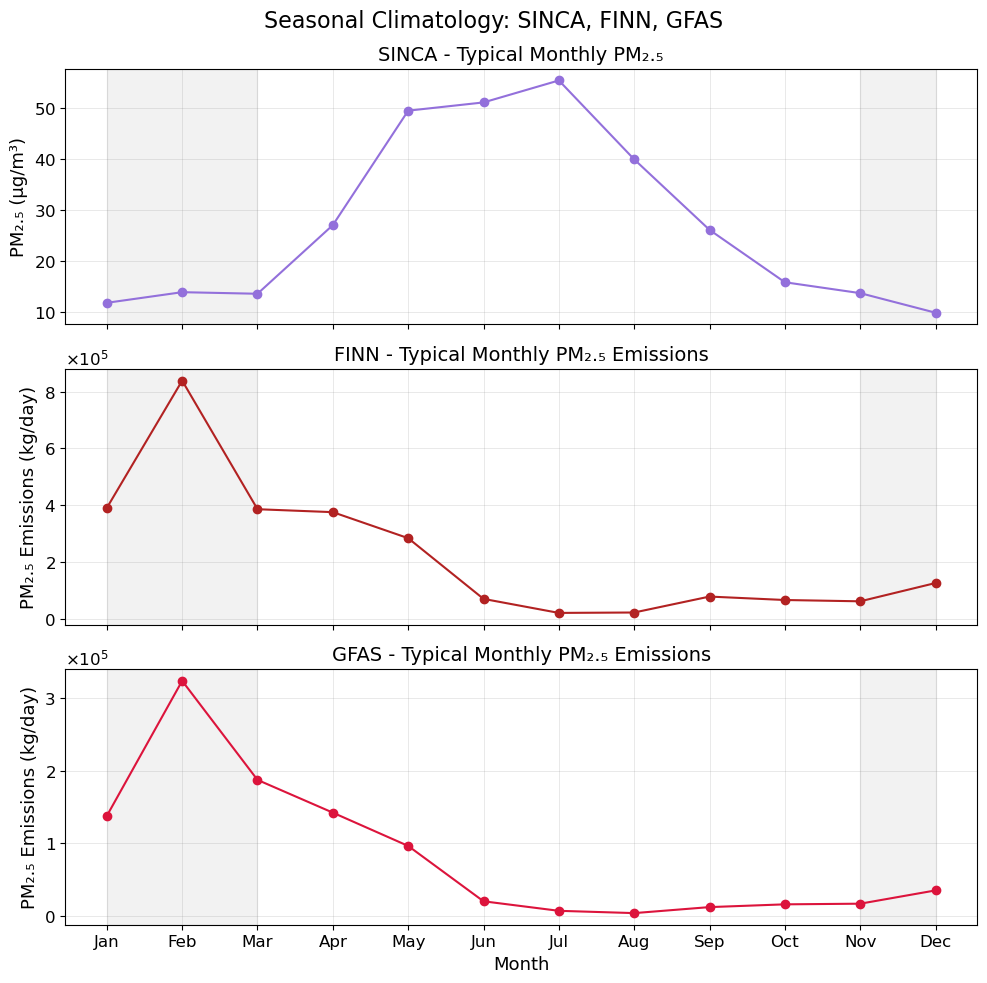

In [29]:
MIN_FIRE_YEAR = 2008

# fire_year already exists on overall_flat_daily and finn_daily_full from earlier steps
overall_flat_daily_clim = overall_flat_daily[overall_flat_daily["fire_year"] >= MIN_FIRE_YEAR].copy()
finn_daily_full_clim = finn_daily_full[finn_daily_full["fire_year"] >= MIN_FIRE_YEAR].copy()

# gfas_daily needs fire_year assigned 
gfas_daily["fire_year"] = gfas_daily["date_only"].apply(assign_fire_year)
gfas_daily_clim = gfas_daily[gfas_daily["fire_year"] >= MIN_FIRE_YEAR].copy()

overall_flat_daily_clim["month"] = overall_flat_daily_clim["date_only"].dt.month
finn_daily_full_clim["month"] = finn_daily_full_clim["date_only"].dt.month
gfas_daily_clim["month"] = gfas_daily_clim["date_only"].dt.month

sinca_clim = overall_flat_daily_clim.groupby("month")["PM25_flat_mean"].mean()
finn_clim = finn_daily_full_clim.groupby("month")["PM25_kg_day_sum"].mean()
gfas_clim = gfas_daily_clim.groupby("month")["gfas_pm25_kg_day"].mean()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(sinca_clim.index, sinca_clim.values, marker="o", color="mediumpurple")
axes[0].set_title(f"SINCA - Typical Monthly PM₂.₅")
axes[0].set_ylabel("PM₂.₅ (µg/m³)")
use_sci_notation(axes[0])

axes[1].plot(finn_clim.index, finn_clim.values, marker="o", color="firebrick")
axes[1].set_title(f"FINN - Typical Monthly PM₂.₅ Emissions")
axes[1].set_ylabel("PM₂.₅ Emissions (kg/day)")
use_sci_notation(axes[1])

axes[2].plot(gfas_clim.index, gfas_clim.values, marker="o", color="crimson")
axes[2].set_title(f"GFAS - Typical Monthly PM₂.₅ Emissions")
axes[2].set_ylabel("PM₂.₅ Emissions (kg/day)")
axes[2].set_xlabel("Month")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels([month_labels[m] for m in range(1, 13)])
use_sci_notation(axes[2])

for ax in axes:
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    ax.axvspan(11, 12, color="gray", alpha=0.1)
    ax.axvspan(1, 3, color="gray", alpha=0.1)

fig.suptitle(f"Seasonal Climatology: SINCA, FINN, GFAS", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/fig_seasonal_climatology_all3.png", dpi=400, bbox_inches="tight")
plt.show()

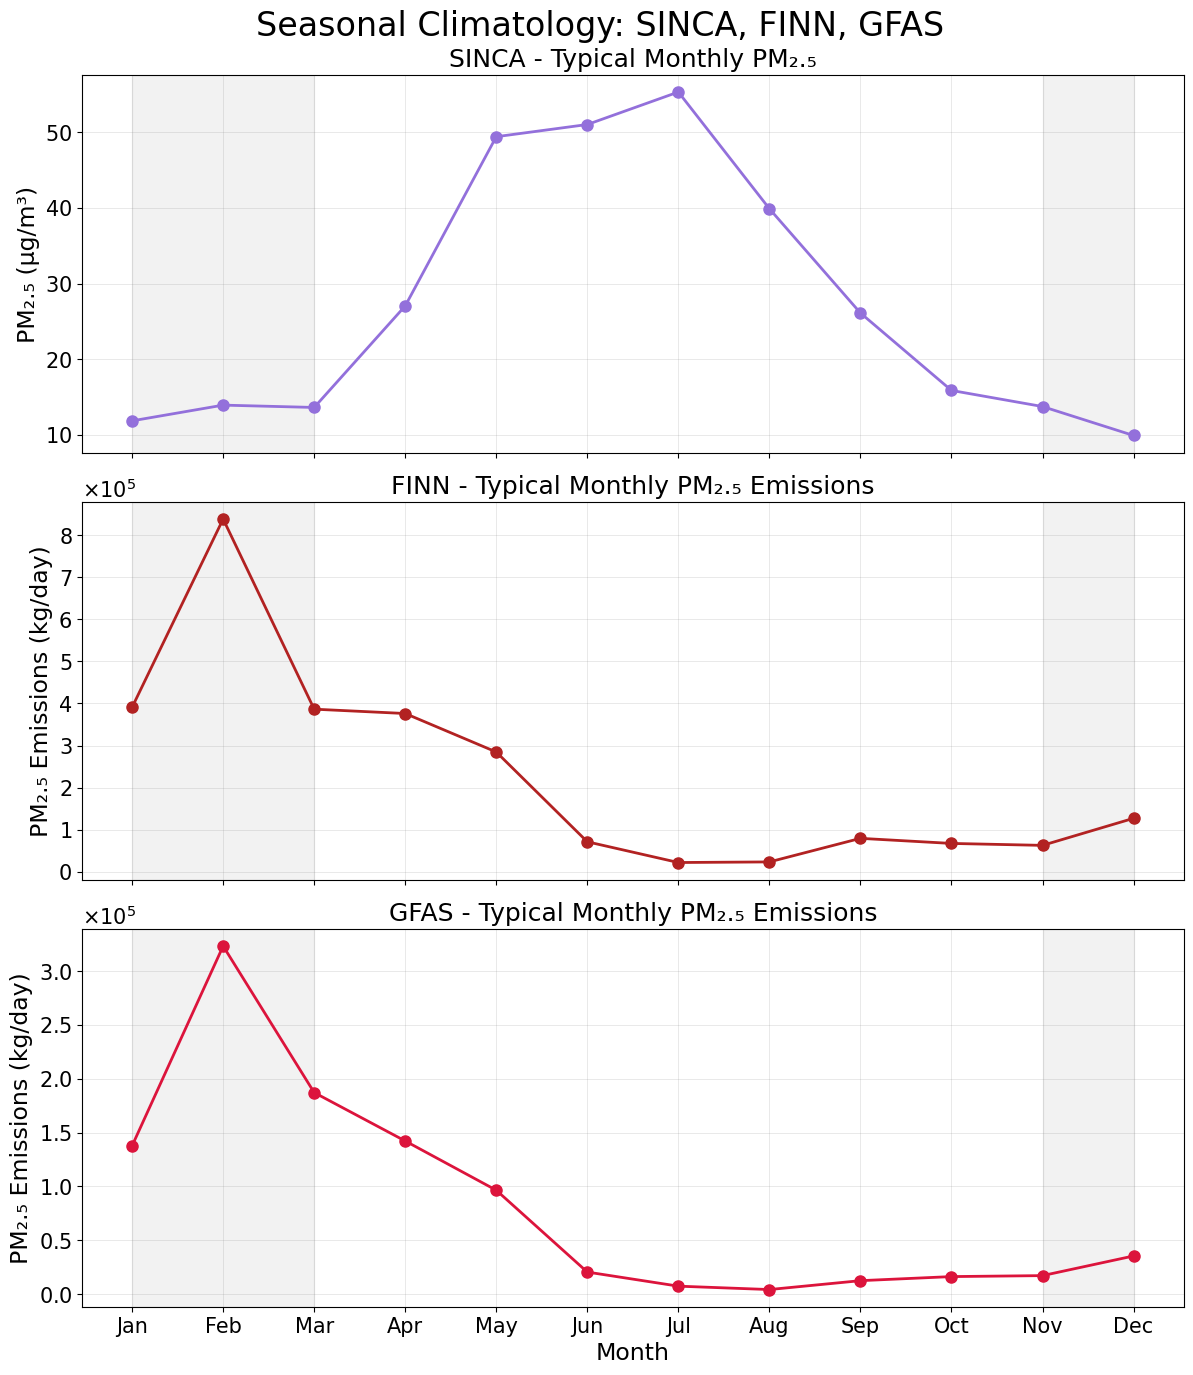

In [30]:
# Poster version of the seasonal climatology figure (larger fonts)
poster_fontsize = {
    "suptitle": 24,
    "title": 18,
    "label": 17,
    "tick": 15,
}

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

axes[0].plot(sinca_clim.index, sinca_clim.values, marker="o", color="mediumpurple", linewidth=2, markersize=8)
axes[0].set_title("SINCA - Typical Monthly PM₂.₅", fontsize=poster_fontsize["title"])
axes[0].set_ylabel("PM₂.₅ (µg/m³)", fontsize=poster_fontsize["label"])
use_sci_notation(axes[0])

axes[1].plot(finn_clim.index, finn_clim.values, marker="o", color="firebrick", linewidth=2, markersize=8)
axes[1].set_title("FINN - Typical Monthly PM₂.₅ Emissions", fontsize=poster_fontsize["title"])
axes[1].set_ylabel("PM₂.₅ Emissions (kg/day)", fontsize=poster_fontsize["label"])
use_sci_notation(axes[1])

axes[2].plot(gfas_clim.index, gfas_clim.values, marker="o", color="crimson", linewidth=2, markersize=8)
axes[2].set_title("GFAS - Typical Monthly PM₂.₅ Emissions", fontsize=poster_fontsize["title"])
axes[2].set_ylabel("PM₂.₅ Emissions (kg/day)", fontsize=poster_fontsize["label"])
axes[2].set_xlabel("Month", fontsize=poster_fontsize["label"])
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels([month_labels[m] for m in range(1, 13)], fontsize=poster_fontsize["tick"])
use_sci_notation(axes[2])

for ax in axes:
    ax.tick_params(axis="both", labelsize=poster_fontsize["tick"])
    ax.yaxis.get_offset_text().set_fontsize(poster_fontsize["tick"])  # enlarge the 1eN offset label
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    ax.axvspan(11, 12, color="gray", alpha=0.1)
    ax.axvspan(1, 3, color="gray", alpha=0.1)

fig.suptitle("Seasonal Climatology: SINCA, FINN, GFAS", fontsize=poster_fontsize["suptitle"])
plt.tight_layout()
plt.savefig("../outputs/fig_seasonal_climatology_all3_poster.png", dpi=400, bbox_inches="tight")
plt.show()

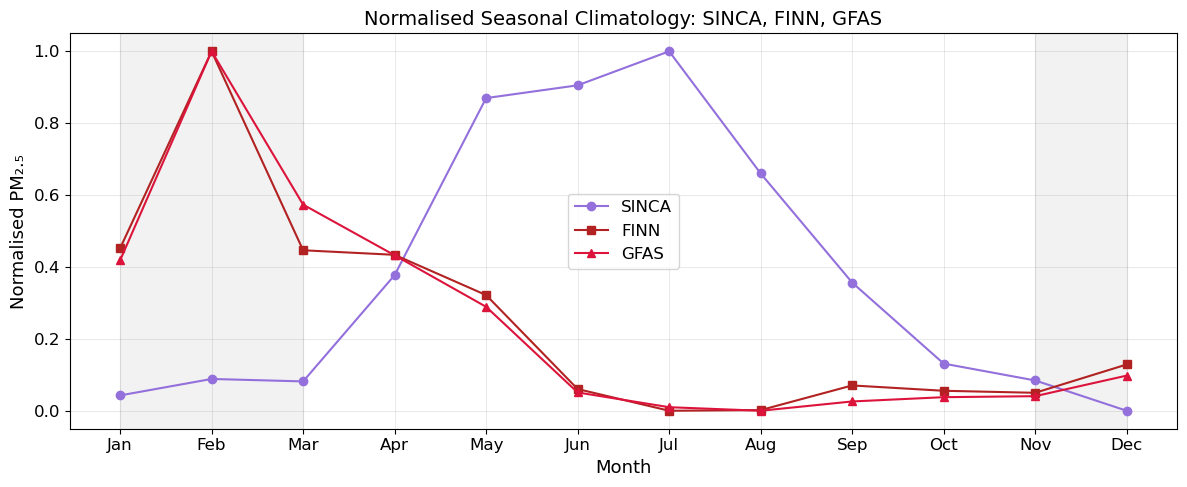

In [31]:
# Normalise each climatology series (min-max scaling, 0 to 1) 
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

sinca_clim_norm = normalize(sinca_clim)
finn_clim_norm = normalize(finn_clim)
gfas_clim_norm = normalize(gfas_clim)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sinca_clim_norm.index, sinca_clim_norm.values, marker="o", color="mediumpurple", label="SINCA")
ax.plot(finn_clim_norm.index, finn_clim_norm.values, marker="s", color="firebrick", label="FINN")
ax.plot(gfas_clim_norm.index, gfas_clim_norm.values, marker="^", color="crimson", label="GFAS")

ax.set_title(f"Normalised Seasonal Climatology: SINCA, FINN, GFAS")
ax.set_ylabel("Normalised PM₂.₅") # 0 = annual min, 1 = annual max
ax.set_xlabel("Month")
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_labels[m] for m in range(1, 13)])
ax.legend()
ax.axvspan(11, 12, color="gray", alpha=0.1)
ax.axvspan(1, 3, color="gray", alpha=0.1)
ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/fig_seasonal_climatology_normalised_all3.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
sinca_annual_flat.to_csv("../outputs/sinca_annual_flat.csv", index=False)
print(f"Saved sinca_annual_flat: {len(sinca_annual_flat)} rows, columns: {list(sinca_annual_flat.columns)}")

Saved sinca_annual_flat: 15 rows, columns: ['fire_year', 'SINCA_flat_mean', 'SINCA_flat_p95']


In [33]:
print(sinca_annual_flat.head(10))
print(sinca_annual_flat.dtypes)

   fire_year  SINCA_flat_mean  SINCA_flat_p95
0       2008        12.034820       22.393744
1       2009        11.645809       17.721492
2       2010        16.404770       26.934363
3       2011        13.555393       19.187896
4       2012        15.481031       20.997151
5       2013        22.403280      100.144531
6       2014        12.263825       24.308353
7       2015        11.794260       21.557043
8       2016        11.148720       17.428185
9       2017        10.027964       14.889802
fire_year            int64
SINCA_flat_mean    float64
SINCA_flat_p95     float64
dtype: object


## SINCA for only DEC-MAR

In [34]:
# SINCA trend restricted to December-March only

def is_dec_mar(date):
    return date.month in [12, 1, 2, 3]

overall_flat_daily["dec_mar"] = overall_flat_daily["date_only"].apply(is_dec_mar)

sinca_decmar_annual = (
    overall_flat_daily[overall_flat_daily["dec_mar"] & (overall_flat_daily["fire_year"] >= 2008)]
    .groupby("fire_year")
    .agg(SINCA_decmar_mean=("PM25_flat_mean", "mean"),
         SINCA_decmar_p95=("PM25_flat_mean", lambda x: x.quantile(0.95)))
    .reset_index()
)

sinca_decmar_valid = sinca_decmar_annual.dropna(subset=["SINCA_decmar_mean"])
print(sinca_decmar_valid)

mk_decmar_mean = mk.original_test(sinca_decmar_valid["SINCA_decmar_mean"])
mk_decmar_p95 = mk.original_test(sinca_decmar_valid["SINCA_decmar_p95"])

print(f"\nSINCA Dec-Mar mean trend: p={mk_decmar_mean.p:.4f}, slope={mk_decmar_mean.slope:.4f}, trend={mk_decmar_mean.trend}")
print(f"SINCA Dec-Mar p95 trend:  p={mk_decmar_p95.p:.4f}, slope={mk_decmar_p95.slope:.4f}, trend={mk_decmar_p95.trend}")

    fire_year  SINCA_decmar_mean  SINCA_decmar_p95
0        2008          11.583709         19.454347
1        2009          10.820729         14.912844
2        2010          17.131300         27.498185
3        2011          13.328542         19.086843
4        2012          15.579715         20.623751
5        2013          14.604700         33.333566
6        2014          13.004525         25.485461
7        2015          12.274106         22.311268
8        2016          11.297760         19.492214
9        2017          10.216601         15.250665
10       2018          11.125343         18.720694
11       2019           9.842771         16.305356
12       2020           9.409938         14.947636
13       2021          11.121485         22.343703
14       2022          13.414403         38.877440

SINCA Dec-Mar mean trend: p=0.0478, slope=-0.2690, trend=decreasing
SINCA Dec-Mar p95 trend:  p=1.0000, slope=-0.0523, trend=no trend


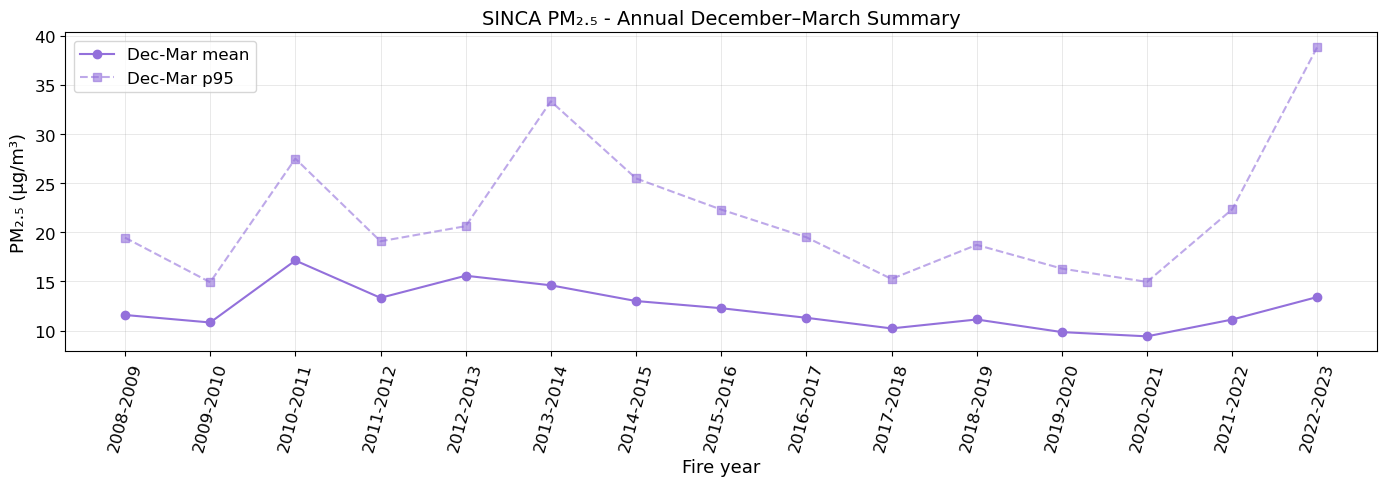

In [35]:
# Time series: SINCA, December-March days only

decmar_daily = overall_flat_daily[overall_flat_daily["dec_mar"]].sort_values("date_only")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sinca_decmar_valid["fire_year"], sinca_decmar_valid["SINCA_decmar_mean"],
        marker="o", color="mediumpurple", label="Dec-Mar mean")
ax.plot(sinca_decmar_valid["fire_year"], sinca_decmar_valid["SINCA_decmar_p95"],
        marker="s", color="mediumpurple", linestyle="--", alpha=0.6, label="Dec-Mar p95")

ax.set_title("SINCA PM₂.₅ - Annual December–March Summary")
ax.set_ylabel("PM₂.₅ (µg/m³)")
ax.set_xlabel("Fire year")
ax.set_xticks(sinca_decmar_valid["fire_year"])
ax.set_xticklabels([f"{int(y)}-{int(y)+1}" for y in sinca_decmar_valid["fire_year"]], rotation=75)
ax.legend()
use_sci_notation(ax)
ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/fig_sinca_decmar_annual.png", dpi=400, bbox_inches="tight")
plt.show()

In [36]:
print(f"SINCA Dec-Mar mean: p={mk_decmar_mean.p:.4f}, Tau={mk_decmar_mean.Tau:.3f}, "
      f"Sen's slope={mk_decmar_mean.slope:.4f}, trend={mk_decmar_mean.trend}")

SINCA Dec-Mar mean: p=0.0478, Tau=-0.390, Sen's slope=-0.2690, trend=decreasing


In [37]:
# FINN and GFAS trend, December-March only

finn_daily_full["dec_mar"] = finn_daily_full["date_only"].apply(is_dec_mar)
gfas_daily["dec_mar"] = gfas_daily["date_only"].apply(is_dec_mar)

finn_decmar_annual = (
    finn_daily_full[finn_daily_full["dec_mar"] & (finn_daily_full["fire_year"] >= 2008)]
    .groupby("fire_year")
    .agg(FINN_decmar_sum=("PM25_kg_day_sum", "sum"))
    .reset_index()
)

gfas_decmar_annual = (
    gfas_daily[gfas_daily["dec_mar"] & (gfas_daily["fire_year"] >= 2008)]
    .groupby("fire_year")
    .agg(GFAS_decmar_sum=("gfas_pm25_kg_day", "sum"))
    .reset_index()
)

mk_finn_decmar = mk.original_test(finn_decmar_annual["FINN_decmar_sum"])
mk_gfas_decmar = mk.original_test(gfas_decmar_annual["GFAS_decmar_sum"])

print(f"FINN Dec-Mar trend: p={mk_finn_decmar.p:.4f}, slope={mk_finn_decmar.slope:.4g}, trend={mk_finn_decmar.trend}")
print(f"GFAS Dec-Mar trend: p={mk_gfas_decmar.p:.4f}, slope={mk_gfas_decmar.slope:.4g}, trend={mk_gfas_decmar.trend}")

print(finn_decmar_annual)
print(gfas_decmar_annual)

FINN Dec-Mar trend: p=0.0101, slope=3.893e+06, trend=increasing
GFAS Dec-Mar trend: p=0.2350, slope=5.581e+05, trend=no trend
    fire_year  FINN_decmar_sum
0        2008     2.690144e+07
1        2009     8.111491e+06
2        2010     1.057694e+07
3        2011     3.066110e+07
4        2012     1.240503e+07
5        2013     3.880876e+07
6        2014     8.268861e+07
7        2015     1.948543e+07
8        2016     8.978756e+07
9        2017     2.770910e+07
10       2018     4.336043e+07
11       2019     4.722953e+07
12       2020     2.588938e+07
13       2021     6.958936e+07
14       2022     2.419669e+08
    fire_year  GFAS_decmar_sum
0        2008     1.118229e+07
1        2009     5.402517e+06
2        2010     8.398246e+06
3        2011     1.725146e+07
4        2012     7.326778e+06
5        2013     1.548001e+07
6        2014     2.122001e+07
7        2015     1.016468e+07
8        2016     3.656140e+07
9        2017     9.867406e+06
10       2018     9.441867e+06
11    

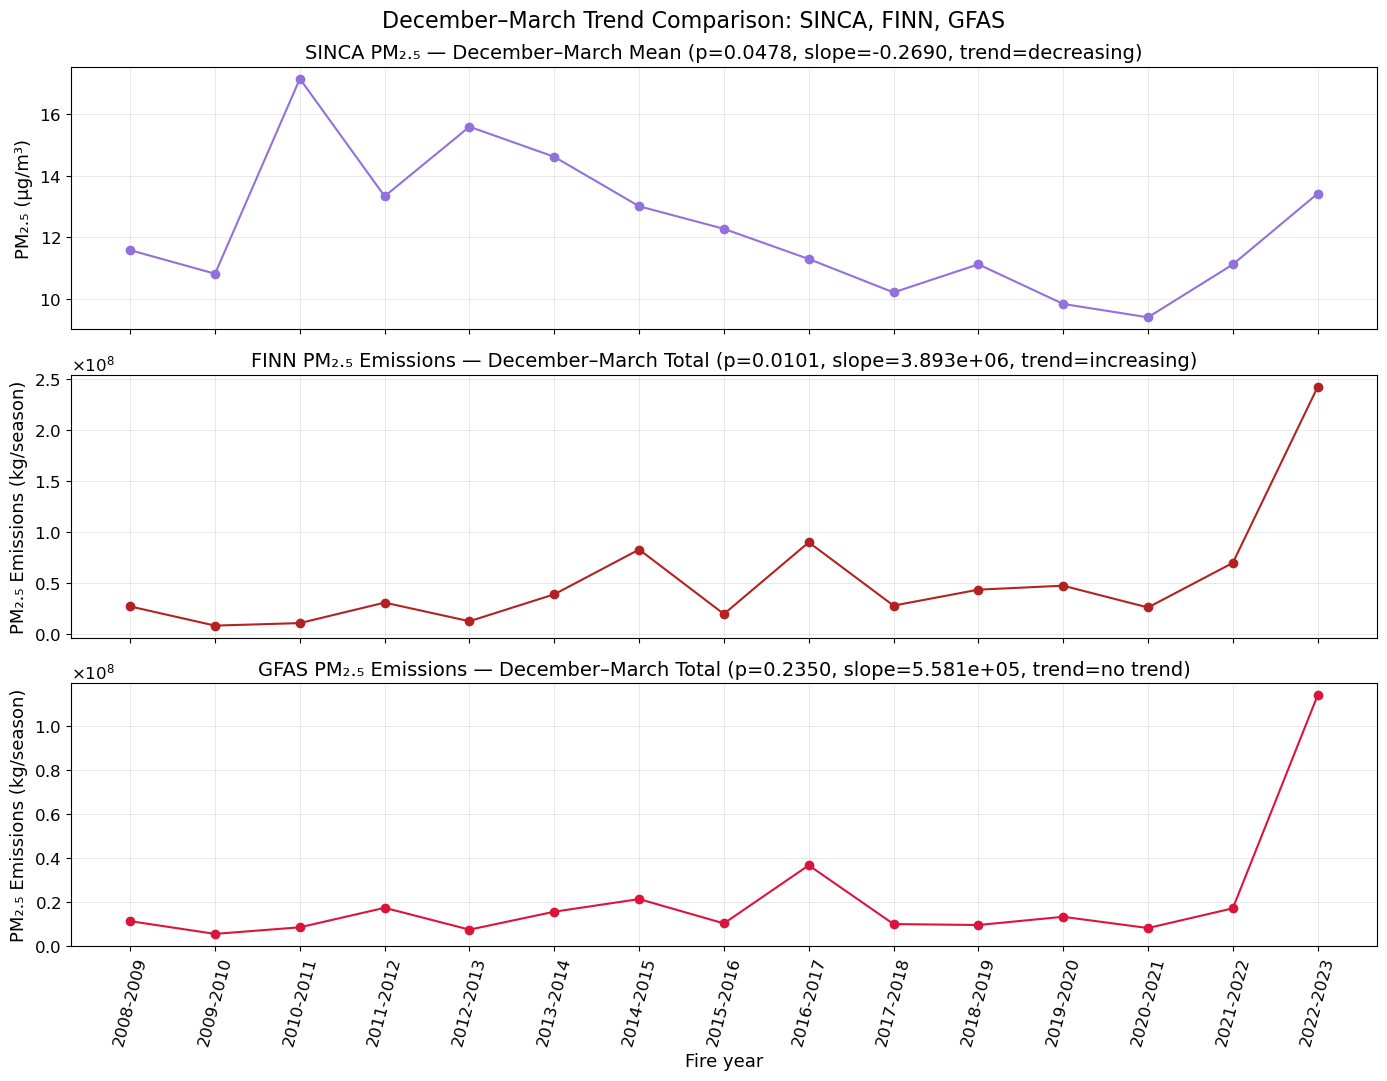

In [38]:
# Three-panel Dec-Mar trend comparison: SINCA, FINN, GFAS - including stats

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(sinca_decmar_valid["fire_year"], sinca_decmar_valid["SINCA_decmar_mean"],
             marker="o", color="mediumpurple")
axes[0].set_title(f"SINCA PM₂.₅ — December–March Mean "
                   f"(p={mk_decmar_mean.p:.4f}, slope={mk_decmar_mean.slope:.4f}, trend={mk_decmar_mean.trend})")
axes[0].set_ylabel("PM₂.₅ (µg/m³)")
use_sci_notation(axes[0])

axes[1].plot(finn_decmar_annual["fire_year"], finn_decmar_annual["FINN_decmar_sum"],
             marker="o", color="firebrick")
axes[1].set_title(f"FINN PM₂.₅ Emissions — December–March Total "
                   f"(p={mk_finn_decmar.p:.4f}, slope={mk_finn_decmar.slope:.4g}, trend={mk_finn_decmar.trend})")
axes[1].set_ylabel("PM₂.₅ Emissions (kg/season)")
use_sci_notation(axes[1])

axes[2].plot(gfas_decmar_annual["fire_year"], gfas_decmar_annual["GFAS_decmar_sum"],
             marker="o", color="crimson")
axes[2].set_title(f"GFAS PM₂.₅ Emissions — December–March Total "
                   f"(p={mk_gfas_decmar.p:.4f}, slope={mk_gfas_decmar.slope:.4g}, trend={mk_gfas_decmar.trend})")
axes[2].set_ylabel("PM₂.₅ Emissions (kg/season)")
axes[2].set_xlabel("Fire year")
axes[2].set_xticks(sinca_decmar_valid["fire_year"])
axes[2].set_xticklabels([f"{int(y)}-{int(y)+1}" for y in sinca_decmar_valid["fire_year"]], rotation=75)
use_sci_notation(axes[2])

for ax in axes:
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("December–March Trend Comparison: SINCA, FINN, GFAS", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/fig_decmar_trend_all3_w_stats.png", dpi=400, bbox_inches="tight")
plt.show()

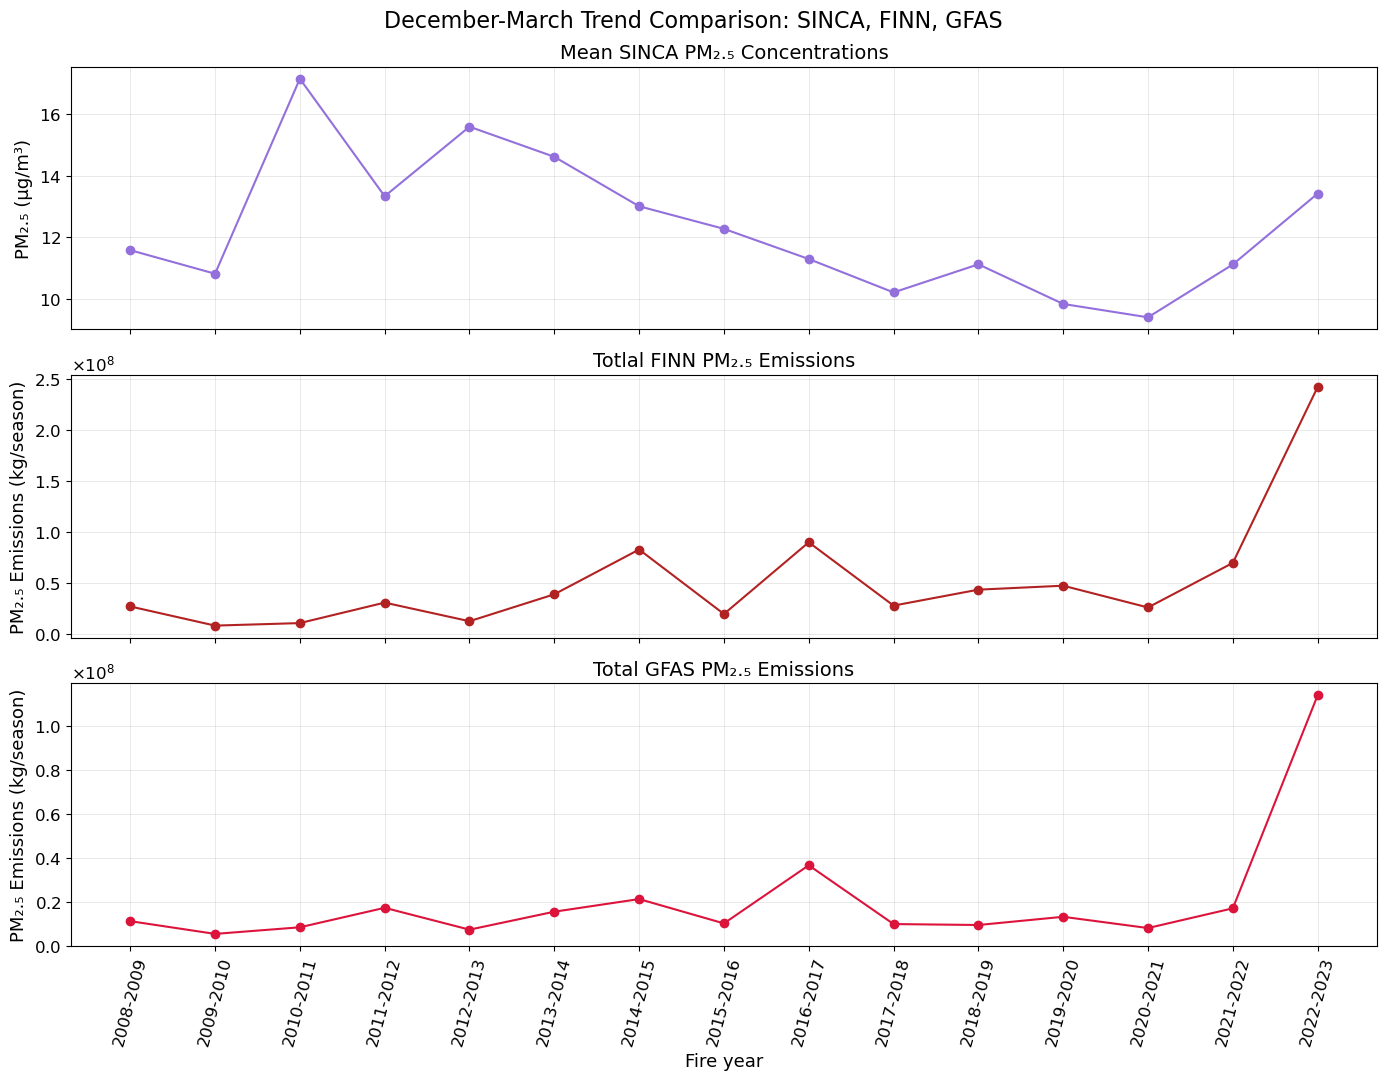

In [39]:
# Three-panel Dec-Mar trend comparison: SINCA, FINN, GFAS 

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(sinca_decmar_valid["fire_year"], sinca_decmar_valid["SINCA_decmar_mean"],
             marker="o", color="mediumpurple")
axes[0].set_title(f"Mean SINCA PM₂.₅ Concentrations")
axes[0].set_ylabel("PM₂.₅ (µg/m³)")
use_sci_notation(axes[0])

axes[1].plot(finn_decmar_annual["fire_year"], finn_decmar_annual["FINN_decmar_sum"],
             marker="o", color="firebrick")
axes[1].set_title(f"Totlal FINN PM₂.₅ Emissions")
axes[1].set_ylabel("PM₂.₅ Emissions (kg/season)")
use_sci_notation(axes[1])

axes[2].plot(gfas_decmar_annual["fire_year"], gfas_decmar_annual["GFAS_decmar_sum"],
             marker="o", color="crimson")
axes[2].set_title(f"Total GFAS PM₂.₅ Emissions")
axes[2].set_ylabel("PM₂.₅ Emissions (kg/season)")
axes[2].set_xlabel("Fire year")
axes[2].set_xticks(sinca_decmar_valid["fire_year"])
axes[2].set_xticklabels([f"{int(y)}-{int(y)+1}" for y in sinca_decmar_valid["fire_year"]], rotation=75)
use_sci_notation(axes[2])

for ax in axes:
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("December-March Trend Comparison: SINCA, FINN, GFAS", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/fig_decmar_trend_all3.png", dpi=400, bbox_inches="tight")
plt.show()

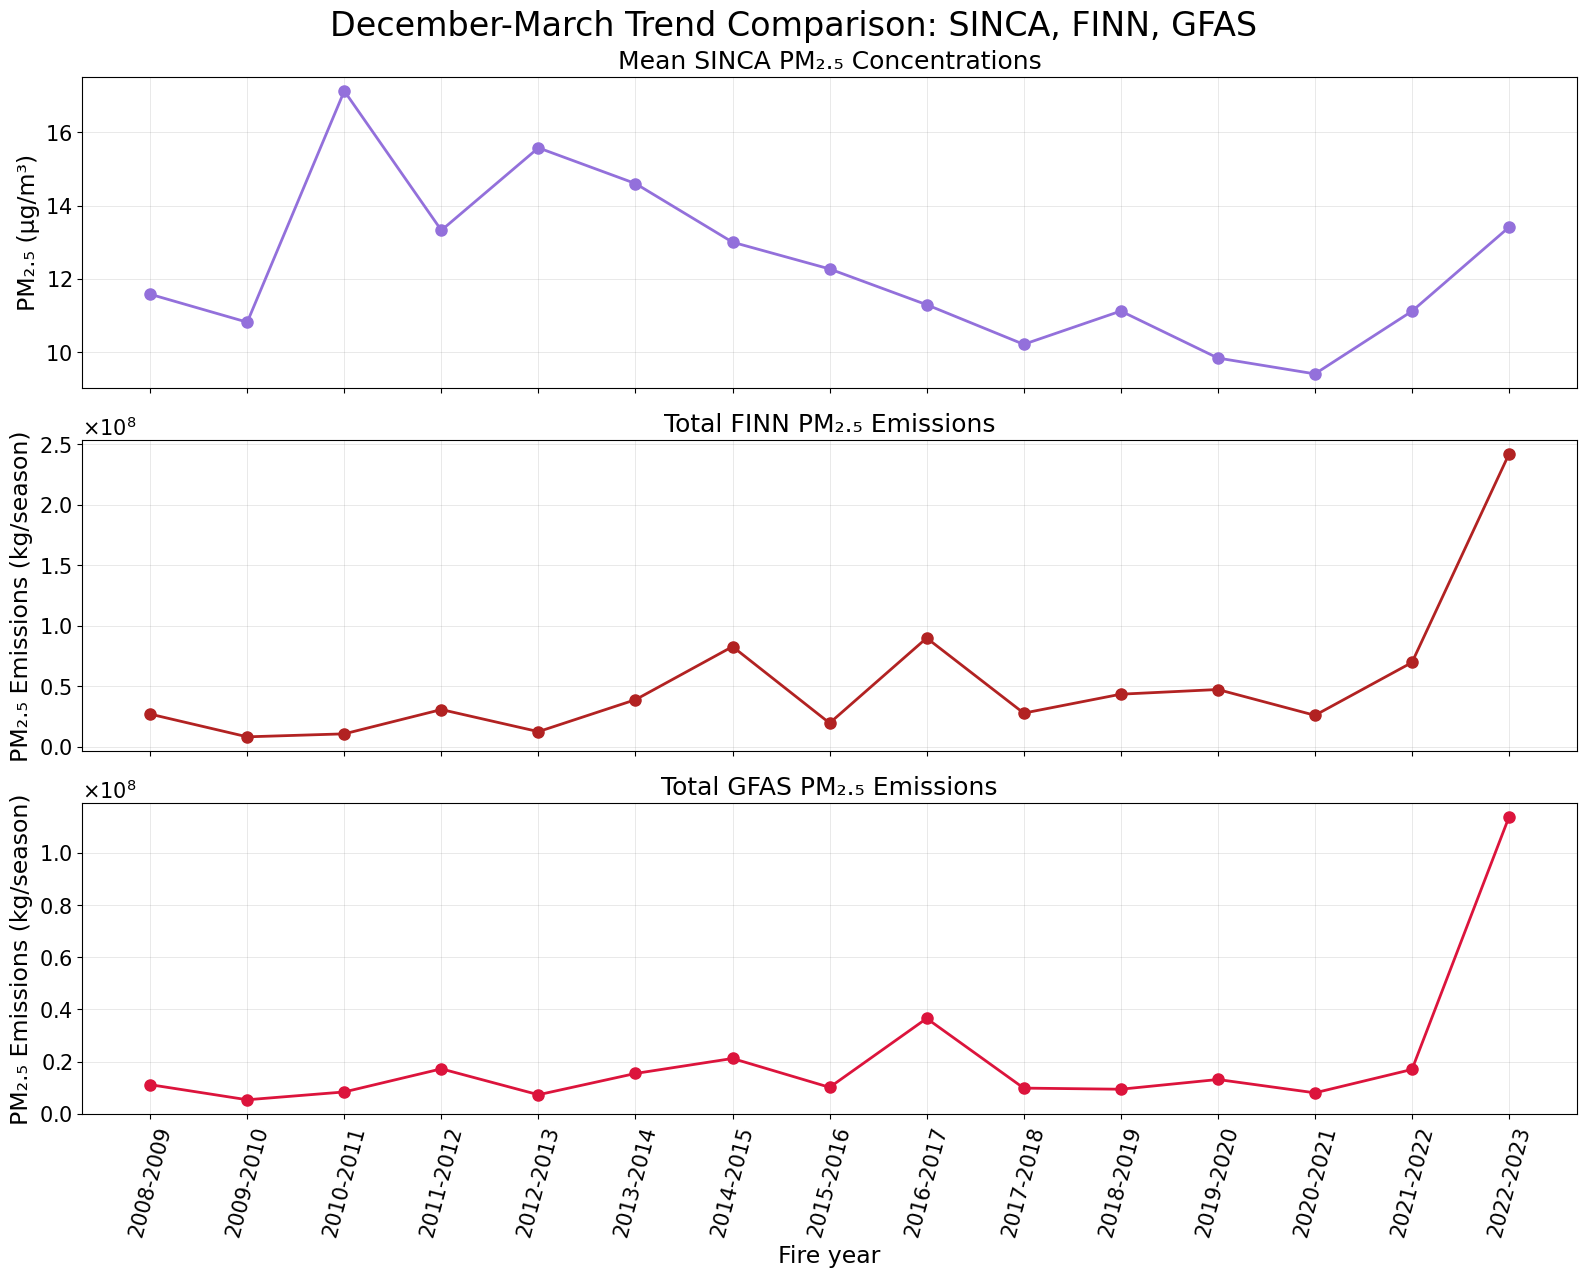

In [40]:
# Poster version of the Dec-Mar trend comparison figure (larger fonts)
poster_fontsize = {
    "suptitle": 24,
    "title": 18,
    "label": 17,
    "tick": 15,
}

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

axes[0].plot(sinca_decmar_valid["fire_year"], sinca_decmar_valid["SINCA_decmar_mean"],
             marker="o", color="mediumpurple", linewidth=2, markersize=8)
axes[0].set_title("Mean SINCA PM₂.₅ Concentrations", fontsize=poster_fontsize["title"])
axes[0].set_ylabel("PM₂.₅ (µg/m³)", fontsize=poster_fontsize["label"])
use_sci_notation(axes[0])

axes[1].plot(finn_decmar_annual["fire_year"], finn_decmar_annual["FINN_decmar_sum"],
             marker="o", color="firebrick", linewidth=2, markersize=8)
axes[1].set_title("Total FINN PM₂.₅ Emissions", fontsize=poster_fontsize["title"])
axes[1].set_ylabel("PM₂.₅ Emissions (kg/season)", fontsize=poster_fontsize["label"])
use_sci_notation(axes[1])

axes[2].plot(gfas_decmar_annual["fire_year"], gfas_decmar_annual["GFAS_decmar_sum"],
             marker="o", color="crimson", linewidth=2, markersize=8)
axes[2].set_title("Total GFAS PM₂.₅ Emissions", fontsize=poster_fontsize["title"])
axes[2].set_ylabel("PM₂.₅ Emissions (kg/season)", fontsize=poster_fontsize["label"])
axes[2].set_xlabel("Fire year", fontsize=poster_fontsize["label"])
axes[2].set_xticks(sinca_decmar_valid["fire_year"])
axes[2].set_xticklabels([f"{int(y)}-{int(y)+1}" for y in sinca_decmar_valid["fire_year"]],
                         rotation=75, fontsize=poster_fontsize["tick"])
use_sci_notation(axes[2])

for ax in axes:
    ax.tick_params(axis="both", labelsize=poster_fontsize["tick"])
    ax.yaxis.get_offset_text().set_fontsize(poster_fontsize["tick"])
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("December-March Trend Comparison: SINCA, FINN, GFAS", fontsize=poster_fontsize["suptitle"])
plt.tight_layout()
plt.savefig("../outputs/fig_decmar_trend_all3_poster.png", dpi=400, bbox_inches="tight")
plt.show()

## Anomalies

In [41]:
# Anomaly / z-score comparison: SINCA vs FINN vs GFAS
anomaly_check = three_way.copy()
for col, label in [("SINCA_mean", "SINCA"), ("FINN_sum", "FINN"), ("pm25_kg_total", "GFAS")]:
    anomaly_check[f"{label}_zscore"] = (anomaly_check[col] - anomaly_check[col].mean()) / anomaly_check[col].std()

print(anomaly_check[["fire_year", "SINCA_zscore", "FINN_zscore", "GFAS_zscore"]])

flagged = anomaly_check[
    (anomaly_check["SINCA_zscore"].abs() > 1.5) |
    (anomaly_check["FINN_zscore"].abs() > 1.5) |
    (anomaly_check["GFAS_zscore"].abs() > 1.5)
].copy()

print("\nYears flagged as anomalous in at least one series:")
print(flagged[["fire_year", "SINCA_zscore", "FINN_zscore", "GFAS_zscore"]])

flagged["agreement"] = flagged.apply(
    lambda row: sum([abs(row["SINCA_zscore"]) > 1.5, abs(row["FINN_zscore"]) > 1.5, abs(row["GFAS_zscore"]) > 1.5]),
    axis=1
)
print(flagged[["fire_year", "agreement"]])

    fire_year  SINCA_zscore  FINN_zscore  GFAS_zscore
6        2008     -0.165988    -0.380224    -0.261822
7        2009     -0.281036    -0.542371    -0.351764
8        2010      1.126402    -0.814669    -0.462705
9        2011      0.283713    -0.572818    -0.234758
10       2012      0.853211    -0.620107    -0.556540
11       2013      2.900429    -0.239016    -0.259000
12       2014     -0.098261     0.693659     0.191561
13       2015     -0.237132    -0.510358    -0.154061
14       2016     -0.428047     0.497818     0.493937
15       2017     -0.759505    -0.448427    -0.529409
16       2018     -0.621388    -0.077857    -0.270931
17       2019     -0.906072    -0.025643    -0.306781
18       2020     -0.999968    -0.434769    -0.569627
19       2021     -0.605881     0.203692    -0.198761
20       2022     -0.060476     3.271089     3.470664

Years flagged as anomalous in at least one series:
    fire_year  SINCA_zscore  FINN_zscore  GFAS_zscore
11       2013      2.900429   

## Corroborating Extreme Values found in other datasets

In [42]:
# Look up a specific date 
target_date = pd.Timestamp("2023-02-04")

specific_day = overall_flat_daily[overall_flat_daily["date_only"] == target_date]
print(f"Flat average PM2.5 on {target_date.date()}:")
print(specific_day[["date_only", "PM25_flat_mean", "fire_year"]])

# individual stations which contributed that day
station_detail = daily_station[daily_station["date_only"] == target_date]
station_detail = station_detail[station_detail["PM25"].notna()]
print(f"\n{len(station_detail)} station(s) reporting on {target_date.date()}:")
print(station_detail[["site", "region", "PM25"]])

# Highest concentration days within a specific fire year 
target_fire_year = 2022  

fire_year_data = overall_flat_daily[overall_flat_daily["fire_year"] == target_fire_year]
top_days = fire_year_data.dropna(subset=["PM25_flat_mean"]).sort_values("PM25_flat_mean", ascending=False)

print(f"\nTop 10 highest flat-average PM2.5 days in fire year {target_fire_year}:")
print(top_days[["date_only", "PM25_flat_mean"]].head(10))

# station-level detail for the single highest day in that fire year
if len(top_days) > 0:
    peak_date = top_days.iloc[0]["date_only"]
    peak_stations = daily_station[daily_station["date_only"] == peak_date]
    peak_stations = peak_stations[peak_stations["PM25"].notna()]
    print(f"\nStation-level detail for the peak day ({peak_date.date()}):")
    print(peak_stations[["site", "region", "PM25"]])

Flat average PM2.5 on 2023-02-04:
      date_only  PM25_flat_mean  fire_year
7523 2023-02-04      107.298013       2022

28 station(s) reporting on 2023-02-04:
             site region        PM25
15193       CHLII   VIII  411.434783
22863        CHYI   VIII   32.458333
38203     CNELIII   VIII   27.608696
53543      CNELIX   VIII   26.291667
61213       CNELV   VIII   22.083333
68883      CNELVI   VIII   18.541667
76553     CNELVII   VIII   34.333333
84223    CNELVIII   VIII   16.125000
91893         CNH   VIII   29.875000
99563        CONC   VIII   17.208333
107233       HPNI   VIII   21.750000
114903      HPNII   VIII   19.791667
122573     HPNIII   VIII   27.958333
130243        HQI   VIII   61.250000
137913        LAI   VIII  442.043478
145583        LAJ   VIII  329.250000
153253       NACI   VIII  407.454545
176263      PLCII     IX   17.833333
199273  RVIII/810   VIII  347.083333
237623  RVIII/874   VIII  420.090909
245293        SCA   VIII  120.086957
260633         TE     IX  

In [43]:
# Look up a specific date - new date to previous cell 
target_date = pd.Timestamp("2015-02-18") 

specific_day = overall_flat_daily[overall_flat_daily["date_only"] == target_date]
print(f"Flat average PM2.5 on {target_date.date()}:")
print(specific_day[["date_only", "PM25_flat_mean", "fire_year"]])

# individual stations which contributed that day
station_detail = daily_station[daily_station["date_only"] == target_date]
station_detail = station_detail[station_detail["PM25"].notna()]
print(f"\n{len(station_detail)} station(s) reporting on {target_date.date()}:")
print(station_detail[["site", "region", "PM25"]])

# Highest concentration days within a specific fire year
target_fire_year = 2014  

fire_year_data = overall_flat_daily[overall_flat_daily["fire_year"] == target_fire_year]
top_days = fire_year_data.dropna(subset=["PM25_flat_mean"]).sort_values("PM25_flat_mean", ascending=False)

print(f"\nTop 10 highest flat-average PM2.5 days in fire year {target_fire_year}:")
print(top_days[["date_only", "PM25_flat_mean"]].head(10))

# station-level detail for the single highest day in that fire year
if len(top_days) > 0:
    peak_date = top_days.iloc[0]["date_only"]
    peak_stations = daily_station[daily_station["date_only"] == peak_date]
    peak_stations = peak_stations[peak_stations["PM25"].notna()]
    print(f"\nStation-level detail for the peak day ({peak_date.date()}):")
    print(peak_stations[["site", "region", "PM25"]])

Flat average PM2.5 on 2015-02-18:
      date_only  PM25_flat_mean  fire_year
4615 2015-02-18       32.266023       2014

8 station(s) reporting on 2015-02-18:
         site region       PM25
12285   CHLII   VIII  36.391948
111995  HPNII   VIII  35.360393
135005    LAI   VIII  51.054988
257725     TE     IX   7.833333
273065  TEIII     IX  11.916667
311415   THNV   VIII  38.710468
319085  THNVI   VIII  49.601642
326755    TME   VIII  27.258742

Top 10 highest flat-average PM2.5 days in fire year 2014:
      date_only  PM25_flat_mean
4391 2014-07-09      161.488801
4390 2014-07-08      111.565617
4401 2014-07-19      106.280575
4392 2014-07-10      105.072173
4711 2015-05-25      102.782770
4713 2015-05-27      100.835767
4740 2015-06-23       96.486212
4387 2014-07-05       94.058654
4427 2014-08-14       88.381153
4739 2015-06-22       85.829012

Station-level detail for the peak day (2014-07-09):
         site region        PM25
12061   CHLII   VIII  171.637046
134781    LAI   VIII  1